Fitted circle parameters:
Center (x, y): (4.95878477360345, -2.9568352844394212)
Radius: 10.036457045924317


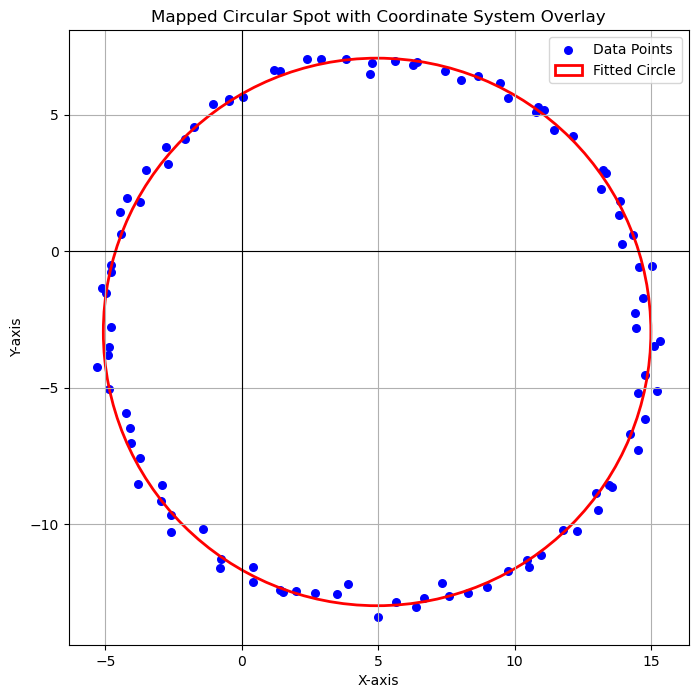

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

def calc_R(x, y, xc, yc):
    """Calculate the distance of each data point from the center (xc, yc)."""
    return np.sqrt((x - xc)**2 + (y - yc)**2)

def residuals(c, x, y):
    """Calculate the residuals between the distances of data points from the center and the radius."""
    xc, yc, r = c
    return calc_R(x, y, xc, yc) - r

# ----------------------------
# Sample data (replace with your actual data)
# ----------------------------
# For demonstration, we generate data points around a circle with some noise.
theta = np.linspace(0, 2 * np.pi, 100)
r_true = 10       # True radius (example)
xc_true = 5       # True x-coordinate of center (example)
yc_true = -3      # True y-coordinate of center (example)

# Generate noisy edge points
x_data = xc_true + r_true * np.cos(theta) + np.random.normal(0, 0.3, theta.shape)
y_data = yc_true + r_true * np.sin(theta) + np.random.normal(0, 0.3, theta.shape)

# ----------------------------
# Circle Fitting
# ----------------------------
# An initial guess for the center can be the mean of the data points
x_m = np.mean(x_data)
y_m = np.mean(y_data)
# An initial guess for the radius can be the mean distance from the initial center guess
r_guess = np.mean(calc_R(x_data, y_data, x_m, y_m))
initial_guess = [x_m, y_m, r_guess]

# Perform the least-squares optimization to fit the circle
fitted_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
xc_fit, yc_fit, r_fit = fitted_params

print("Fitted circle parameters:")
print("Center (x, y):", (xc_fit, yc_fit))
print("Radius:", r_fit)

# ----------------------------
# Plotting: Data, Fitted Circle, and Coordinate Axes
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x_data, y_data, label='Data Points', color='blue', s=30)

# Create a circle patch using the fitted parameters
circle_patch = plt.Circle((xc_fit, yc_fit), r_fit, color='red', fill=False, lw=2, label='Fitted Circle')
ax.add_patch(circle_patch)

# Overlay the coordinate system (x and y axes)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)

# Setting equal aspect ratio to ensure the circle is not distorted
ax.set_aspect('equal', adjustable='box')

# Labels, legend, and grid for clarity
ax.set_title("Mapped Circular Spot with Coordinate System Overlay")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.legend()
ax.grid(True)

plt.show()


Fitted Circle Parameters (after de-warping):
Center (x, y): (4.9427646160844425, -3.010633669151867)
Radius: 9.982327332934927


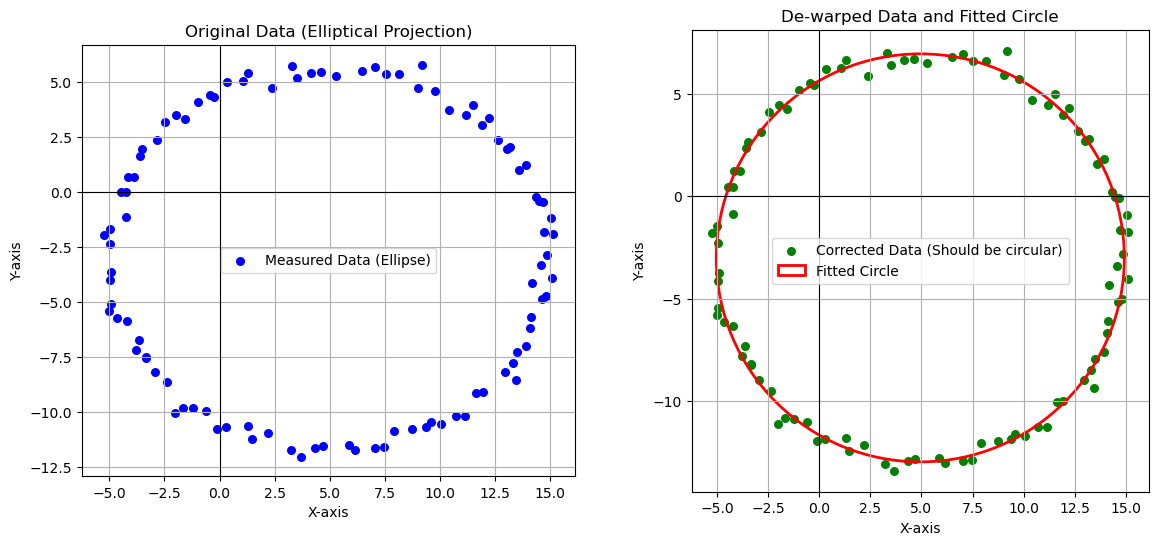

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# --- Sample Data ---
# Let's assume these are your measured laser hit coordinates (ellipse due to tilt)
# Replace these with your actual data
theta = np.linspace(0, 2 * np.pi, 100)
true_radius = 10
true_center = np.array([5, -3])
# Assume the circle is tilted by 30 degrees from the normal in the y-direction.
tilt_angle_deg = 30
tilt_angle_rad = np.deg2rad(tilt_angle_deg)
# Generate perfect circle points
x_circle = true_center[0] + true_radius * np.cos(theta)
y_circle = true_center[1] + true_radius * np.sin(theta)
# Apply the tilt: scale y-coordinates
x_ellipse = x_circle.copy()
y_ellipse = true_center[1] + (y_circle - true_center[1]) * np.cos(tilt_angle_rad)
# Add some noise to simulate measurement error
noise_level = 0.3
x_data = x_ellipse + np.random.normal(0, noise_level, theta.shape)
y_data = y_ellipse + np.random.normal(0, noise_level, theta.shape)

# --- Approach 1: De-warp the Data Using Known Tilt ---
# Correct the y-values by dividing by cos(tilt_angle) to recover the circle
y_data_corrected = (y_data - true_center[1]) / np.cos(tilt_angle_rad) + true_center[1]

# --- Fit a Circle to the Corrected Data ---
def calc_R(x, y, xc, yc):
    return np.sqrt((x - xc)**2 + (y - yc)**2)

def residuals(c, x, y):
    xc, yc, r = c
    return calc_R(x, y, xc, yc) - r

# Use the mean of the corrected data as an initial guess for the center
x_m = np.mean(x_data)
y_m = np.mean(y_data_corrected)
r_guess = np.mean(calc_R(x_data, y_data_corrected, x_m, y_m))
initial_guess = [x_m, y_m, r_guess]

# Least-squares circle fitting on corrected data
fitted_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data_corrected))
xc_fit, yc_fit, r_fit = fitted_params

print("Fitted Circle Parameters (after de-warping):")
print("Center (x, y):", (xc_fit, yc_fit))
print("Radius:", r_fit)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original (elliptical) data with the coordinate axes
ax1.scatter(x_data, y_data, label='Measured Data (Ellipse)', color='blue', s=30)
ax1.axhline(0, color='black', lw=0.8)
ax1.axvline(0, color='black', lw=0.8)
ax1.set_title("Original Data (Elliptical Projection)")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_aspect('equal', adjustable='box')
ax1.legend()
ax1.grid(True)

# Plot the de-warped (corrected) data and fitted circle
ax2.scatter(x_data, y_data_corrected, label='Corrected Data (Should be circular)', color='green', s=30)
fitted_circle = plt.Circle((xc_fit, yc_fit), r_fit, color='red', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(fitted_circle)
ax2.axhline(0, color='black', lw=0.8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title("De-warped Data and Fitted Circle")
ax2.set_xlabel("X-axis")
ax2.set_ylabel("Y-axis")
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
ax2.grid(True)

plt.show()


Fitted Circle Parameters (after de-warping):
Center (x, y): (6.068786722071624, 7.0300472502578515)
Radius: 0.12921561009889457


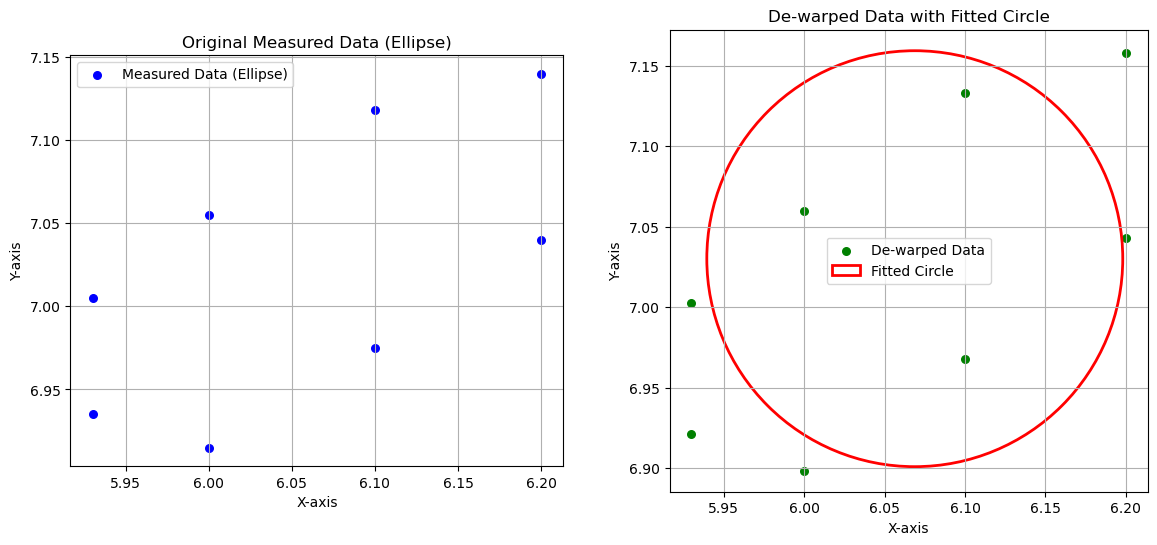

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# INPUT YOUR MEASURED DATA HERE
# =====================================================
# Replace the "..." with your measured data points.
# Make sure that x_data and y_data are lists or NumPy arrays of the same length.
# For example:
# x_data = np.array([1.0, 2.0, 3.0, ...])
# y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([5.93,5.93,6.00,6.00,6.1,6.1,6.2,6.2])  # <-- Insert your x coordinates here
y_data = np.array([6.935,7.005,6.915,7.055,6.975,7.118,7.04,7.14])  # <-- Insert your y coordinates here

# =====================================================
# INPUT THE KNOWN TILT ANGLE (in degrees)
# =====================================================
# This is the angle between the normal to the circular spot and your viewing direction.
# If you don't know it exactly, you can try a best guess.
tilt_angle_deg = 30  # <-- Replace with your tilt angle (degrees) if known
tilt_angle_rad = np.deg2rad(tilt_angle_deg)

# =====================================================
# DE-WARPING THE DATA
# =====================================================
# When viewing a circle at an angle, it appears as an ellipse.
# A simple correction is to "stretch" the y-values to recover the circle.
# We use the estimated center (mean of the data) for the correction.
x_center_est = np.mean(x_data)
y_center_est = np.mean(y_data)

# Correct the y-coordinates:
y_data_corrected = (y_data - y_center_est) / np.cos(tilt_angle_rad) + y_center_est

# =====================================================
# CIRCLE FITTING FUNCTIONS
# =====================================================
def calc_R(x, y, xc, yc):
    """Calculate distances from the point (xc, yc) to all points (x, y)."""
    return np.sqrt((x - xc)**2 + (y - yc)**2)

def residuals(c, x, y):
    """Compute the residuals between the distances of data points from the candidate circle
    (centered at (xc, yc) with radius r) and the candidate radius."""
    xc, yc, r = c
    return calc_R(x, y, xc, yc) - r

# =====================================================
# CIRCLE FITTING ON THE DE-WARPED DATA
# =====================================================
# Use the mean of the data as an initial guess for the center, and the mean distance as an initial radius guess.
r_guess = np.mean(calc_R(x_data, y_data_corrected, x_center_est, y_center_est))
initial_guess = [x_center_est, y_center_est, r_guess]

# Fit the circle using least squares optimization.
fitted_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data_corrected))
xc_fit, yc_fit, r_fit = fitted_params

print("Fitted Circle Parameters (after de-warping):")
print("Center (x, y):", (xc_fit, yc_fit))
print("Radius:", r_fit)

# =====================================================
# PLOTTING THE RESULTS
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original Measured Data (Elliptical Projection)
ax1.scatter(x_data, y_data, label='Measured Data (Ellipse)', color='blue', s=30)
# ax1.axhline(0, color='black', lw=0.8)
# ax1.axvline(0, color='black', lw=0.8)
ax1.set_title("Original Measured Data (Ellipse)")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_aspect('equal', adjustable='box')
ax1.legend()
ax1.grid(True)

# Plot 2: Corrected Data with Fitted Circle
ax2.scatter(x_data, y_data_corrected, label='De-warped Data', color='green', s=30)
fitted_circle = plt.Circle((xc_fit, yc_fit), r_fit, color='red', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(fitted_circle)
# ax2.axhline(0, color='black', lw=0.8)
# ax2.axvline(0, color='black', lw=0.8)
ax2.set_title("De-warped Data with Fitted Circle")
ax2.set_xlabel("X-axis")
ax2.set_ylabel("Y-axis")
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
ax2.grid(True)

plt.show()


Optimized Parameters:
Scale factor in x (a): 522578095429628.25
Scale factor in y (b): 197149962821962.94
Rotation angle (theta, in radians): 4997533.04487757
Fitted circle radius (r): 3.147733886046278e-16


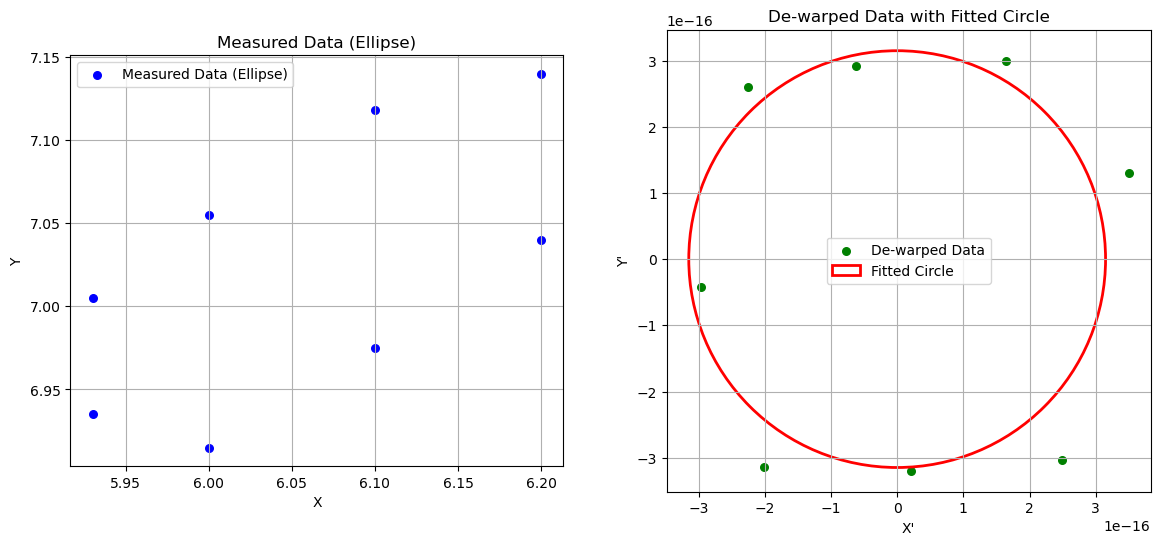

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA HERE
# =====================================================
# Replace the [...] with your measured data.
# For example:
# x_data = np.array([1.0, 2.0, 3.0, ...])
# y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([5.93,5.93,6.00,6.00,6.1,6.1,6.2,6.2])  # <-- Insert your x coordinates here
y_data = np.array([6.935,7.005,6.915,7.055,6.975,7.118,7.04,7.14])  # <-- Insert your y coordinates here

# Compute the centroid (assumed to be the projected center of the true circle)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE RESIDUAL FUNCTION FOR OPTIMIZATION
# =====================================================
# We parameterize the de-warping transformation with:
#   a: scale factor in x
#   b: scale factor in y
#   theta: rotation angle (in radians)
#   r: the true circle’s radius in the de-warped coordinate system
#
# The transformation is:
#   x' = ((x - xm)*cos(theta) + (y - ym)*sin(theta)) / a
#   y' = (-(x - xm)*sin(theta) + (y - ym)*cos(theta)) / b
#
# For a perfect circle (centered at the origin), we would have:
#   sqrt(x'^2 + y'^2) = r
# for all points. The residual is the difference between the computed radius and r.
def residuals(params, x, y):
    a, b, theta, r = params
    # Shift data by the measured centroid
    dx = x - xm
    dy = y - ym
    # Apply the de-warping transformation
    x_prime = (dx * np.cos(theta) + dy * np.sin(theta)) / a
    y_prime = (-dx * np.sin(theta) + dy * np.cos(theta)) / b
    # Residual: the difference between the distance from (0,0) and r
    return np.sqrt(x_prime**2 + y_prime**2) - r

# =====================================================
# 3. INITIAL GUESS AND OPTIMIZATION
# =====================================================
# Use initial guesses:
# a = 1, b = 1 (i.e. no scaling correction),
# theta = 0 (no rotation),
# r = average distance from the centroid in the measured data.
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 1.0, 0.0, r0]

# Run the least-squares optimization to find the best de-warping parameters.
opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
a_opt, b_opt, theta_opt, r_opt = opt_params

print("Optimized Parameters:")
print("Scale factor in x (a):", a_opt)
print("Scale factor in y (b):", b_opt)
print("Rotation angle (theta, in radians):", theta_opt)
print("Fitted circle radius (r):", r_opt)

# =====================================================
# 4. COMPUTE THE DE-WARPED DATA USING THE OPTIMIZED PARAMETERS
# =====================================================
dx = x_data - xm
dy = y_data - ym
x_prime = (dx * np.cos(theta_opt) + dy * np.sin(theta_opt)) / a_opt
y_prime = (-dx * np.sin(theta_opt) + dy * np.cos(theta_opt)) / b_opt

# =====================================================
# 5. PLOTTING THE RESULTS
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Measured Data (Elliptical Projection)
ax1.scatter(x_data, y_data, label='Measured Data (Ellipse)', color='blue', s=30)
# ax1.axhline(0, color='black', lw=0.8)
# ax1.axvline(0, color='black', lw=0.8)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title("Measured Data (Ellipse)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()
ax1.grid(True)

# Plot 2: De-warped Data and Fitted Circle
ax2.scatter(x_prime, y_prime, label='De-warped Data', color='green', s=30)
# Draw the fitted circle (centered at (0,0) in de-warped coordinates)
fitted_circle = plt.Circle((0, 0), r_opt, color='red', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(fitted_circle)
# ax2.axhline(0, color='black', lw=0.8)
# ax2.axvline(0, color='black', lw=0.8)
ax2.set_aspect('equal', adjustable='box')
ax2.set_title("De-warped Data with Fitted Circle")
ax2.set_xlabel("X'")
ax2.set_ylabel("Y'")
ax2.legend()
ax2.grid(True)

plt.show()


Optimized parameters:
  Scale factor in v (b): 3.3591945050598135
  Shear factor (c): -0.003289458933792583
  Rotation angle (theta, in radians): 99081.68348272817
  Fitted circle radius (r): 0.07520428214059806
Angle between new coordinate axes (degrees): 90.6330887229091


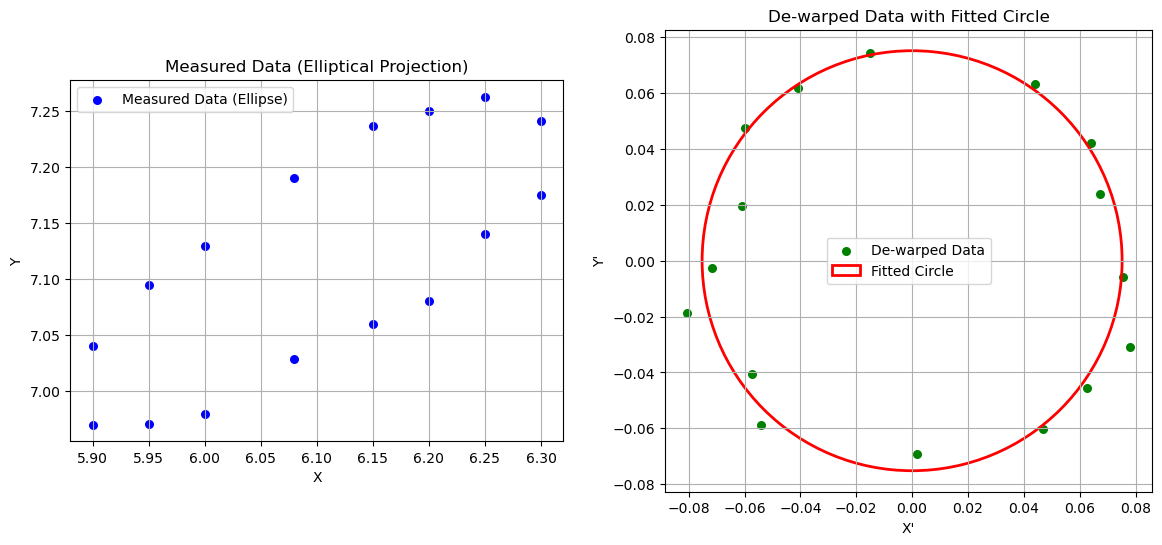

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA HERE
# =====================================================
# Replace the placeholder [...] with your measured data.
# For example:
#   x_data = np.array([1.0, 2.0, 3.0, ...])
#   y_data = np.array([4.0, 5.0, 6.0, ...])
# x_data = np.array([5.93,5.93,6.00,6.00,6.1,6.1,6.2,6.2])  # <-- Insert your x coordinates here
# y_data = np.array([6.935,7.005,6.915,7.055,6.975,7.118,7.04,7.14])  # <-- Insert your y coordinates here
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE RESIDUAL FUNCTION FOR OPTIMIZATION
# =====================================================
# Our transformation:
#   1. Rotate the data by theta:
#         u = cos(theta)*(x - xm) + sin(theta)*(y - ym)
#         v = -sin(theta)*(x - xm) + cos(theta)*(y - ym)
#   2. Apply an affine map that includes a shear (with shear parameter c) and a scaling in v (with factor b).
#      We “fix” the scaling in u to 1.
#         x' = u + c*v
#         y' = v / b
# For a perfect circle (centered at the origin) we require:
#         sqrt((x')^2 + (y')^2) = r
# The residual for each data point is then:
#         sqrt((u + c*v)^2 + (v/b)^2) - r
def residuals(params, x, y):
    b, c, theta, r = params
    # Shift the data so that the centroid is at the origin
    dx = x - xm
    dy = y - ym
    # Rotate by theta
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    # Apply the affine (shear+scaling) transformation:
    x_prime = u + c * v      # (Note: scaling for u is fixed to 1)
    y_prime = v / b
    # Compute the radial distance in the transformed coordinates and subtract the fitted radius
    return np.sqrt(x_prime**2 + y_prime**2) - r

# =====================================================
# 3. INITIAL GUESS AND OPTIMIZATION
# =====================================================
# Initial guesses:
#   - b: set to 1 (no scaling in v initially)
#   - c: set to 0 (axes perpendicular initially)
#   - theta: 0 (no rotation initially)
#   - r: mean distance from the centroid (using the untransformed data)
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

# Run the least-squares optimizer to find the best-fit parameters
opt_params, success = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized parameters:")
print("  Scale factor in v (b):", b_opt)
print("  Shear factor (c):", c_opt)
print("  Rotation angle (theta, in radians):", theta_opt)
print("  Fitted circle radius (r):", r_opt)

# Compute the angle between the new coordinate axes.
# In the transformed space, the new x-axis is defined by the vector (1, 0)
# and the new y-axis by (c, 1/b). Their dot product is c.
# The lengths are: ||e1|| = 1, and ||e2|| = sqrt(c^2 + (1/b)^2).
# Thus, the angle phi between them is:
phi = np.arccos( c_opt / np.sqrt(c_opt**2 + (1/b_opt)**2) )
phi_deg = np.degrees(phi)
print("Angle between new coordinate axes (degrees):", phi_deg)

# =====================================================
# 4. COMPUTE THE TRANSFORMED (DE-WARPED) DATA
# =====================================================
dx = x_data - xm
dy = y_data - ym
u = dx * np.cos(theta_opt) + dy * np.sin(theta_opt)
v = -dx * np.sin(theta_opt) + dy * np.cos(theta_opt)
x_prime = u + c_opt * v
y_prime = v / b_opt

# =====================================================
# 5. PLOTTING THE RESULTS
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Measured Data (elliptical projection)
ax1.scatter(x_data, y_data, label='Measured Data (Ellipse)', color='blue', s=30)
# ax1.axhline(0, color='black', lw=0.8)
# ax1.axvline(0, color='black', lw=0.8)
ax1.set_title("Measured Data (Elliptical Projection)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_aspect('equal', adjustable='box')
ax1.legend()
ax1.grid(True)

# Plot 2: De-warped Data and Fitted Circle
ax2.scatter(x_prime, y_prime, label='De-warped Data', color='green', s=30)
# Plot the circle (centered at the origin in the de-warped coordinates)
circle = plt.Circle((0, 0), r_opt, color='red', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(circle)
# ax2.axhline(0, color='black', lw=0.8)
# ax2.axvline(0, color='black', lw=0.8)
ax2.set_title("De-warped Data with Fitted Circle")
ax2.set_xlabel("X'")
ax2.set_ylabel("Y'")
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
ax2.grid(True)

plt.show()


Optimized parameters:
  Scale factor in v (b): 3.3591945050598135
  Shear factor (c): -0.003289458933792583
  Rotation angle (theta, in radians): 99081.68348272817
  Fitted circle radius (r): 0.07520428214059806
Angle between new coordinate axes (degrees): 90.6330887229091

De-warped coordinates (points mapped onto the circle):
Point 0: x' = -0.057, y' = -0.041
Point 1: x' = 0.047, y' = -0.060
Point 2: x' = -0.081, y' = -0.019
Point 3: x' = 0.063, y' = -0.046
Point 4: x' = -0.061, y' = 0.020
Point 5: x' = 0.076, y' = -0.006
Point 6: x' = -0.060, y' = 0.048
Point 7: x' = 0.067, y' = 0.024
Point 8: x' = -0.041, y' = 0.062
Point 9: x' = 0.064, y' = 0.042
Point 10: x' = -0.015, y' = 0.074
Point 11: x' = 0.044, y' = 0.063
Point 12: x' = -0.072, y' = -0.003
Point 13: x' = 0.078, y' = -0.031
Point 14: x' = 0.002, y' = -0.069
Point 15: x' = -0.054, y' = -0.059


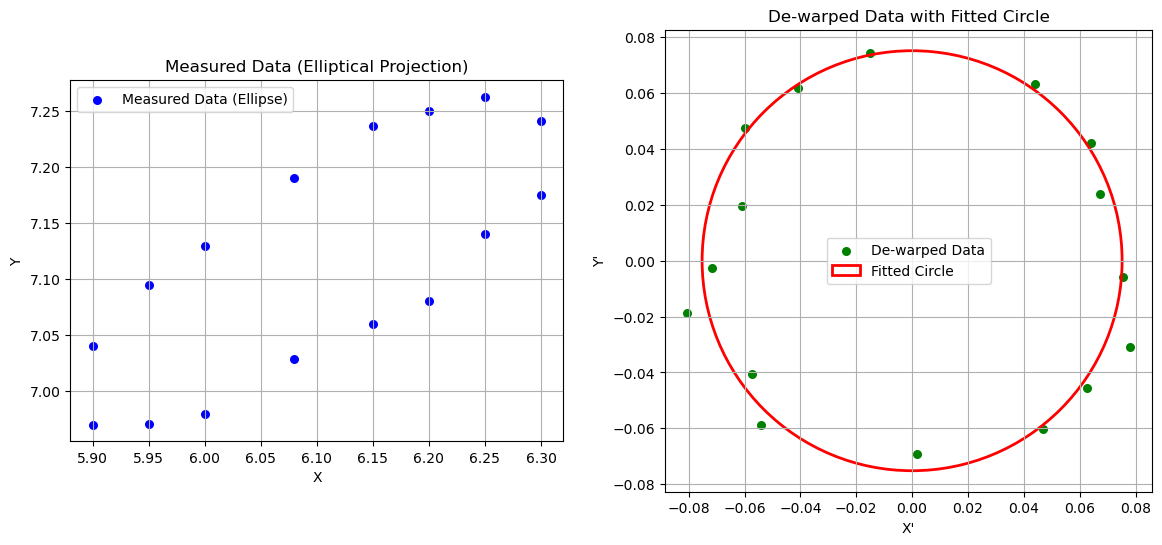

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA HERE
# =====================================================
# Replace the placeholder [...] with your measured data.
# For example:
#    x_data = np.array([1.0, 2.0, 3.0, ...])
#    y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE RESIDUAL FUNCTION FOR OPTIMIZATION
# =====================================================
# Our transformation:
#   1. Rotate the data by theta:
#         u = cos(theta)*(x - xm) + sin(theta)*(y - ym)
#         v = -sin(theta)*(x - xm) + cos(theta)*(y - ym)
#   2. Apply an affine map that includes a shear (with shear parameter c) and
#      a scaling in v (with factor b). We “fix” the scaling in u to 1.
#         x' = u + c*v
#         y' = v / b
# For a perfect circle (centered at the origin) we require:
#         sqrt((x')^2 + (y')^2) = r
# The residual for each data point is then:
#         sqrt((u + c*v)^2 + (v/b)^2) - r
def residuals(params, x, y):
    b, c, theta, r = params
    # Shift the data so that the centroid is at the origin.
    dx = x - xm
    dy = y - ym
    # Rotate by theta:
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    # Apply the affine (shear+scaling) transformation:
    x_prime = u + c * v      # (Scaling in u is fixed to 1)
    y_prime = v / b
    # Residual: the difference between the distance from the origin and r.
    return np.sqrt(x_prime**2 + y_prime**2) - r

# =====================================================
# 3. INITIAL GUESS AND OPTIMIZATION
# =====================================================
# Initial guesses:
#   - b: set to 1 (no scaling correction for v initially)
#   - c: set to 0 (axes perpendicular initially)
#   - theta: 0 (no rotation initially)
#   - r: average distance from the centroid (using the untransformed data)
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

# Run the least-squares optimizer to find the best-fit parameters
opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized parameters:")
print("  Scale factor in v (b):", b_opt)
print("  Shear factor (c):", c_opt)
print("  Rotation angle (theta, in radians):", theta_opt)
print("  Fitted circle radius (r):", r_opt)

# (Optional) Compute the angle between the new coordinate axes.
# In the transformed space, the x-axis is along (1, 0) and the y-axis is along (c, 1/b).
# Their dot product is c, and the angle phi between them is:
phi = np.arccos( c_opt / np.sqrt(c_opt**2 + (1/b_opt)**2) )
phi_deg = np.degrees(phi)
print("Angle between new coordinate axes (degrees):", phi_deg)

# =====================================================
# 4. COMPUTE THE TRANSFORMED (DE-WARPED) DATA
# =====================================================
dx = x_data - xm
dy = y_data - ym
u = dx * np.cos(theta_opt) + dy * np.sin(theta_opt)
v = -dx * np.sin(theta_opt) + dy * np.cos(theta_opt)
x_prime = u + c_opt * v
y_prime = v / b_opt

# =====================================================
# 5. PRINT THE DE-WARPED COORDINATES
# =====================================================
print("\nDe-warped coordinates (points mapped onto the circle):")
for i, (xp, yp) in enumerate(zip(x_prime, y_prime)):
    print(f"Point {i}: x' = {xp:.3f}, y' = {yp:.3f}")

# =====================================================
# 6. PLOTTING THE RESULTS
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Measured Data (elliptical projection)
ax1.scatter(x_data, y_data, label='Measured Data (Ellipse)', color='blue', s=30)
# ax1.axhline(0, color='black', lw=0.8)
# ax1.axvline(0, color='black', lw=0.8)
ax1.set_title("Measured Data (Elliptical Projection)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_aspect('equal', adjustable='box')
ax1.legend()
ax1.grid(True)

# Plot 2: De-warped Data with Fitted Circle
ax2.scatter(x_prime, y_prime, label='De-warped Data', color='green', s=30)
# Plot the fitted circle (centered at the origin in the de-warped coordinates)
circle = plt.Circle((0, 0), r_opt, color='red', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(circle)
# ax2.axhline(0, color='black', lw=0.8)
# ax2.axvline(0, color='black', lw=0.8)
ax2.set_title("De-warped Data with Fitted Circle")
ax2.set_xlabel("X'")
ax2.set_ylabel("Y'")
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
ax2.grid(True)

plt.show()


Optimized parameters:
  Scale factor in v (b): 3.3591945050598135
  Shear factor (c): -0.003289458933792583
  Rotation angle (theta, in radians): 99081.68348272817
  Fitted circle radius (r): 0.07520428214059806


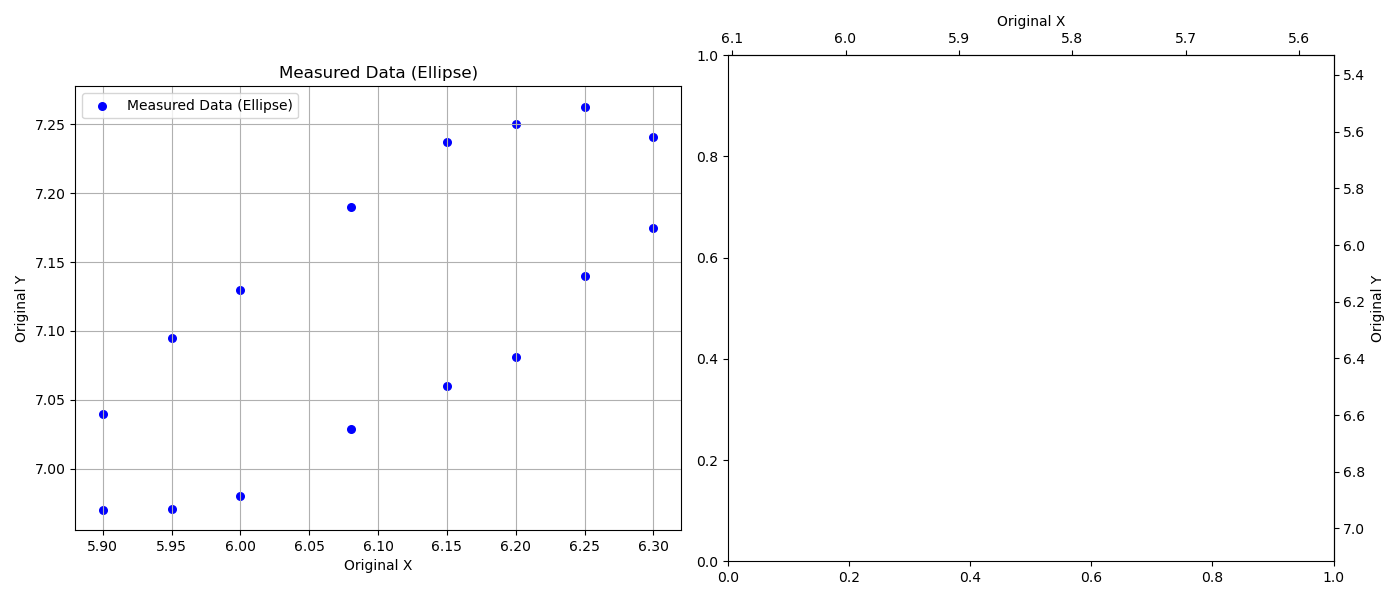

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA HERE
# =====================================================
# Replace the placeholder [...] with your measured data.
# For example:
#    x_data = np.array([1.0, 2.0, 3.0, ...])
#    y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid of the measured data (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE RESIDUAL FUNCTION FOR OPTIMIZATION
# =====================================================
# Here we allow for a rotation (theta), a shear (c), and a scaling (b) in one direction.
# (We “fix” the scaling in the u-direction to 1.) After subtracting the centroid,
# we compute:
#
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#
# Then the de-warped coordinates are:
#
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at the origin), we expect:
#
#   sqrt((x')^2 + (y')^2) = r
#
# The residual for each point is:
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# =====================================================
# 3. INITIAL GUESS AND OPTIMIZATION
# =====================================================
# Initial guesses:
#   b = 1 (no scaling in v initially)
#   c = 0 (no shear initially, i.e. perpendicular axes)
#   theta = 0 (no rotation initially)
#   r = average distance from the centroid in the measured data.
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized parameters:")
print("  Scale factor in v (b):", b_opt)
print("  Shear factor (c):", c_opt)
print("  Rotation angle (theta, in radians):", theta_opt)
print("  Fitted circle radius (r):", r_opt)

# =====================================================
# 4. COMPUTE THE DE-WARPED (CIRCLED) DATA
# =====================================================
dx = x_data - xm
dy = y_data - ym
u = dx * np.cos(theta_opt) + dy * np.sin(theta_opt)
v = -dx * np.sin(theta_opt) + dy * np.cos(theta_opt)
x_prime = u + c_opt * v
y_prime = v / b_opt

# =====================================================
# 5. SET UP THE MAPPING BETWEEN DE-WARPED AND ORIGINAL AXES
# =====================================================
# The transformation from original (x,y) to de-warped (x',y') can be written as:
#
#   [x']   = [ A    B ] [x - xm]
#   [y']     [ C    D ] [y - ym]
#
# where:
A = np.cos(theta_opt) - c_opt * np.sin(theta_opt)
B = np.sin(theta_opt) + c_opt * np.cos(theta_opt)
C = -np.sin(theta_opt) / b_opt
D = np.cos(theta_opt) / b_opt

# Compute the determinant and the inverse transformation matrix M_inv.
det = A * D - B * C
M_inv = np.array([[D, -B],
                  [-C, A]]) / det
# M_inv maps [x'; y'] to [x - xm; y - ym]

# For the secondary axes we assume that along the de-warped x'-axis (i.e. y'=0),
# the original x coordinate is given by:
#   x = xm + M_inv[0,0] * x'
# and similarly along the de-warped y'-axis (x'=0),
#   y = ym + M_inv[1,1] * y'
#
# Define the one-dimensional mapping functions:
def xprime_to_orig(xp):
    return xm + M_inv[0,0] * xp

def orig_to_xprime(xorig):
    return (xorig - xm) / M_inv[0,0]

def yprime_to_orig(yp):
    return ym + M_inv[1,1] * yp

def orig_to_yprime(yorig):
    return (yorig - ym) / M_inv[1,1]

# =====================================================
# 6. PLOTTING: SHOW BOTH ELLIPTICAL AND DE-WARPED DATA
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Original (elliptical) measured data with its own coordinate axes.
ax1.scatter(x_data, y_data, label='Measured Data (Ellipse)', color='blue', s=30)
# ax1.axhline(0, color='black', lw=0.8)
# ax1.axvline(0, color='black', lw=0.8)
ax1.set_title("Measured Data (Ellipse)")
ax1.set_xlabel("Original X")
ax1.set_ylabel("Original Y")
ax1.set_aspect('equal', adjustable='box')
ax1.legend()
ax1.grid(True)

# Right plot: De-warped data (which should lie on a circle).
# ax2.scatter(x_prime, y_prime, label='De-warped Data', color='green', s=30)
# # Draw the fitted circle (centered at 0,0 in de-warped coordinates)
# circle = plt.Circle((0, 0), r_opt, color='red', fill=False, lw=2, label='Fitted Circle')
# ax2.add_patch(circle)
# # ax2.axhline(0, color='black', lw=0.8)
# # ax2.axvline(0, color='black', lw=0.8)
# ax2.set_title("De-warped Data (Circle)")
# ax2.set_xlabel("De-warped X'")  # de-warped axis
# ax2.set_ylabel("De-warped Y'")
# ax2.set_aspect('equal', adjustable='box')
# ax2.legend()
# ax2.grid(True)

# Draw arrows for the de-warped coordinate axes.
# Here we choose an arbitrary length (e.g., 1.2*r_opt) for visualization.
arrow_length = 1.2 * r_opt
# ax2.arrow(0, 0, arrow_length, 0, head_width=0.05*r_opt, head_length=0.1*r_opt, fc='k', ec='k')
# ax2.arrow(0, 0, 0, arrow_length, head_width=0.05*r_opt, head_length=0.1*r_opt, fc='k', ec='k')
# ax2.text(arrow_length, 0, "  X'", va='center', fontsize=10)
# ax2.text(0, arrow_length, "  Y'", ha='center', fontsize=10)

# =====================================================
# 7. ADD SECONDARY AXES TO THE DE-WARPED PLOT
# =====================================================
# These secondary axes (top and right) will show the original coordinates corresponding
# to positions along the de-warped axes (assuming y'=0 for the x mapping and x'=0 for y).
secax_x = ax2.secondary_xaxis('top', functions=(xprime_to_orig, orig_to_xprime))
secax_x.set_xlabel('Original X')
secax_y = ax2.secondary_yaxis('right', functions=(yprime_to_orig, orig_to_yprime))
secax_y.set_ylabel('Original Y')

plt.tight_layout()
plt.show()


In [49]:
%matplotlib widget

Optimized de-warping parameters:
  b (scaling for v): 3.3591945050598135
  c (shear): -0.003289458933792583
  theta (radians): 99081.68348272817
  r (circle radius): 0.07520428214059806


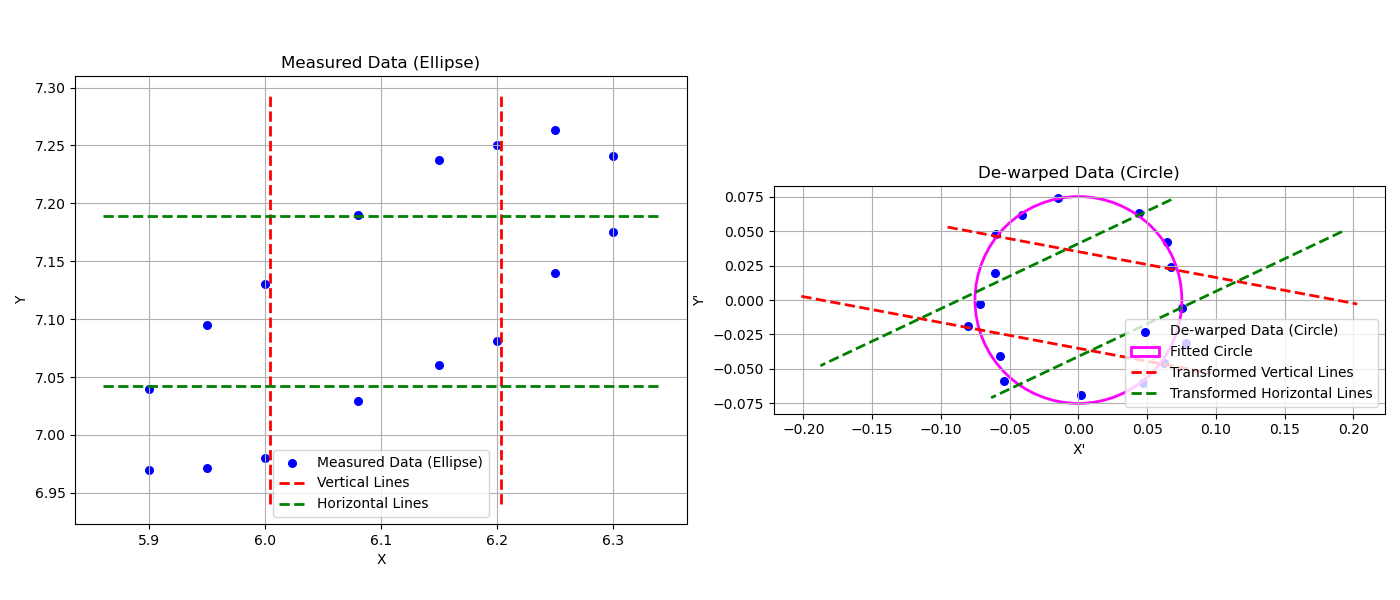

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA (ELLIPSE) HERE
# =====================================================
# Replace the [...] with your measured data.
# For example:
#    x_data = np.array([1.0, 2.0, 3.0, ...])
#    y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE DE-WARPING TRANSFORMATION VIA OPTIMIZATION
# =====================================================
# We assume that the measured ellipse can be de-warped to a circle
# using a transformation that (after centering) first rotates the data by theta,
# then applies an affine mapping with a shear parameter (c) and a scaling factor (b)
#
# The transformation is:
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at 0,0) we want:
#   sqrt((x')^2 + (y')^2) = r   (for all points)
#
# Thus, the residual for each data point is:
#   residual = sqrt((x')^2 + (y')^2) - r
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# Initial guesses:
#   b = 1 (no scaling correction for v initially)
#   c = 0 (no shear initially so axes are perpendicular)
#   theta = 0 (no rotation initially)
#   r = average distance from the centroid in the measured data.
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]

# Run the least-squares optimizer
opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized de-warping parameters:")
print(f"  b (scaling for v): {b_opt}")
print(f"  c (shear): {c_opt}")
print(f"  theta (radians): {theta_opt}")
print(f"  r (circle radius): {r_opt}")

# =====================================================
# 3. DEFINE A HELPER FUNCTION TO APPLY THE TRANSFORMATION
# =====================================================
def transform_points(x, y, xm, ym, theta, c, b):
    """
    Given arrays of x and y (measured coordinates),
    apply the de-warping transformation:
      - Center the data (subtract xm, ym)
      - Rotate by theta
      - Apply shear (c) and scaling (b) to obtain (x', y')
    """
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return x_prime, y_prime

# Transform the measured data points to the de-warped (circle) coordinates.
x_prime, y_prime = transform_points(x_data, y_data, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 4. DEFINE VERTICAL AND HORIZONTAL LINES ON THE ELLIPSE
# =====================================================
# We'll choose two vertical lines (constant x) and two horizontal lines (constant y)
# For illustration, choose lines through the centroid ± one-quarter of the data range.
x_min, x_max = np.min(x_data), np.max(x_data)
y_min, y_max = np.min(y_data), np.max(y_data)
delta_x = (x_max - x_min) / 4.0
delta_y = (y_max - y_min) / 4.0

# Vertical lines at:
vline1 = xm - delta_x
vline2 = xm + delta_x

# Horizontal lines at:
hline1 = ym - delta_y
hline2 = ym + delta_y

# For plotting the lines, we generate points along each line.
# For vertical lines (x fixed), let y vary over a range with a little extra padding.
pad_y = 0.1 * (y_max - y_min)
y_line_vals = np.linspace(y_min - pad_y, y_max + pad_y, 200)

# For horizontal lines (y fixed), let x vary.
pad_x = 0.1 * (x_max - x_min)
x_line_vals = np.linspace(x_min - pad_x, x_max + pad_x, 200)

# Create arrays for the vertical lines:
x_vline1 = np.full_like(y_line_vals, vline1)
x_vline2 = np.full_like(y_line_vals, vline2)

# Create arrays for the horizontal lines:
y_hline1 = np.full_like(x_line_vals, hline1)
y_hline2 = np.full_like(x_line_vals, hline2)

# =====================================================
# 5. APPLY THE TRANSFORMATION TO THE LINE POINTS
# =====================================================
# Transform vertical line points.
vline1_trans_x, vline1_trans_y = transform_points(x_vline1, y_line_vals, xm, ym, theta_opt, c_opt, b_opt)
vline2_trans_x, vline2_trans_y = transform_points(x_vline2, y_line_vals, xm, ym, theta_opt, c_opt, b_opt)

# Transform horizontal line points.
hline1_trans_x, hline1_trans_y = transform_points(x_line_vals, y_hline1, xm, ym, theta_opt, c_opt, b_opt)
hline2_trans_x, hline2_trans_y = transform_points(x_line_vals, y_hline2, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 6. PLOT THE RESULTS
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ----- Left Plot: Original Measured Data (Ellipse) -----
ax1.scatter(x_data, y_data, color='blue', s=30, label='Measured Data (Ellipse)')
# Draw vertical lines on the ellipse.
ax1.plot([vline1, vline1], [y_min - pad_y, y_max + pad_y], 'r--', linewidth=2, label='Vertical Lines')
ax1.plot([vline2, vline2], [y_min - pad_y, y_max + pad_y], 'r--', linewidth=2)
# Draw horizontal lines on the ellipse.
ax1.plot([x_min - pad_x, x_max + pad_x], [hline1, hline1], 'g--', linewidth=2, label='Horizontal Lines')
ax1.plot([x_min - pad_x, x_max + pad_x], [hline2, hline2], 'g--', linewidth=2)
ax1.set_title("Measured Data (Ellipse)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend(loc='best')
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True)

# ----- Right Plot: De-warped Data (Circle) -----
ax2.scatter(x_prime, y_prime, color='blue', s=30, label='De-warped Data (Circle)')
# Draw the fitted circle (centered at (0,0) in the de-warped space).
circle = plt.Circle((0, 0), r_opt, color='magenta', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(circle)
# Plot the transformed vertical lines.
ax2.plot(vline1_trans_x, vline1_trans_y, 'r--', linewidth=2, label='Transformed Vertical Lines')
ax2.plot(vline2_trans_x, vline2_trans_y, 'r--', linewidth=2)
# Plot the transformed horizontal lines.
ax2.plot(hline1_trans_x, hline1_trans_y, 'g--', linewidth=2, label='Transformed Horizontal Lines')
ax2.plot(hline2_trans_x, hline2_trans_y, 'g--', linewidth=2)
ax2.set_title("De-warped Data (Circle)")
ax2.set_xlabel("X'")
ax2.set_ylabel("Y'")
ax2.legend(loc='best')
ax2.set_aspect('equal', adjustable='box')
ax2.grid(True)

plt.tight_layout()
plt.show()


Optimized de-warping parameters:
  b (scaling for v): 3.3591945050598135
  c (shear): -0.003289458933792583
  theta (radians): 99081.68348272817
  r (circle radius): 0.07520428214059806


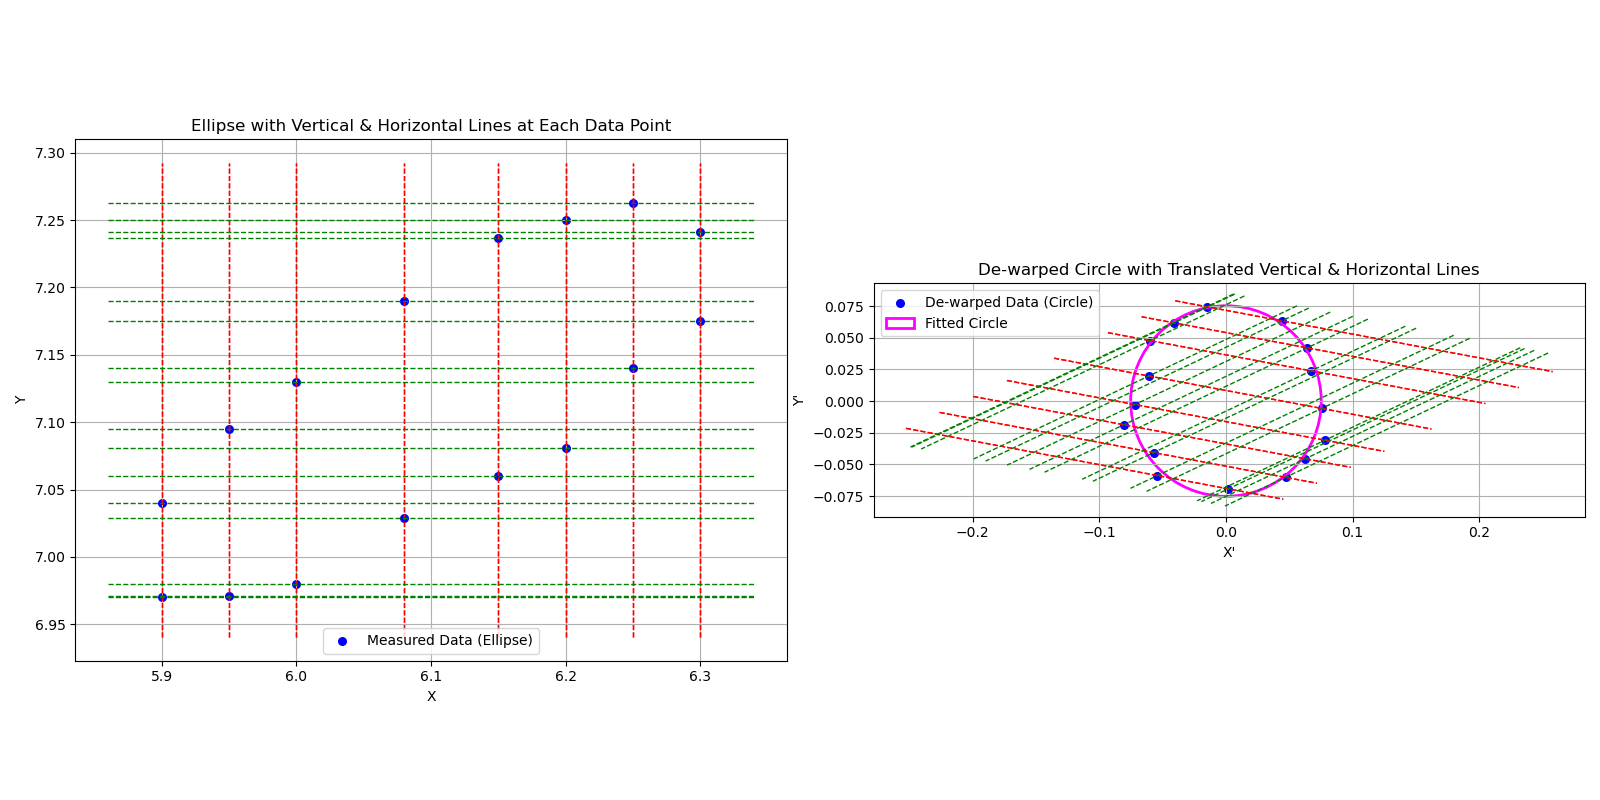

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA (ELLIPSE) HERE
# =====================================================
# Replace the [...] with your measured data.
# For example:
#   x_data = np.array([1.0, 2.0, 3.0, ...])
#   y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE DE-WARPING TRANSFORMATION VIA OPTIMIZATION
# =====================================================
# We assume the ellipse can be de-warped to a circle by first centering the data,
# then rotating by an angle (theta), and finally applying an affine mapping with a
# shear (c) and a scaling (b) in one direction.
#
# The transformation is:
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at 0,0) we want:
#   sqrt((x')^2 + (y')^2) = r
#
# So the residual function is defined as:
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# Initial guesses:
#   b = 1 (no scaling correction for v initially)
#   c = 0 (no shear, so axes are perpendicular)
#   theta = 0 (no rotation initially)
#   r = average distance from the centroid (using the measured data)
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]

# Run the least-squares optimizer to determine the best-fit parameters.
opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized de-warping parameters:")
print("  b (scaling for v):", b_opt)
print("  c (shear):", c_opt)
print("  theta (radians):", theta_opt)
print("  r (circle radius):", r_opt)

# =====================================================
# 3. DEFINE A HELPER FUNCTION TO APPLY THE TRANSFORMATION
# =====================================================
def transform_points(x, y, xm, ym, theta, c, b):
    """
    Given arrays of x and y (measured coordinates), this function:
      - Subtracts the centroid (xm, ym),
      - Rotates the data by theta,
      - Applies an affine transformation with shear c and scaling b,
    to yield the de-warped coordinates (x', y').
    """
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return x_prime, y_prime

# Transform the measured data to obtain the de-warped (circular) coordinates.
x_prime, y_prime = transform_points(x_data, y_data, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 4. CREATE VERTICAL & HORIZONTAL LINES AT EACH DATA POINT (ELLIPSE)
# =====================================================
# We'll create a vertical line at each measured x-value and a horizontal line at each measured y-value.
# For each line, we'll extend it over the full range of the measured data (with a little padding).

# Determine the range of your measured data.
x_min, x_max = np.min(x_data), np.max(x_data)
y_min, y_max = np.min(y_data), np.max(y_data)
pad_x = 0.1 * (x_max - x_min)
pad_y = 0.1 * (y_max - y_min)

# We'll store the line data in lists.
vertical_lines_ellipse = []      # List of tuples: (x_line, y_line) for vertical lines in the ellipse plot
vertical_lines_transformed = []  # Corresponding transformed vertical lines
horizontal_lines_ellipse = []    # List of tuples: (x_line, y_line) for horizontal lines in the ellipse plot
horizontal_lines_transformed = []  # Corresponding transformed horizontal lines

num_line_points = 200  # Number of points to sample for each line

# For every measured x value, create a vertical line (x fixed, y varying)
for x_val in x_data:
    y_line = np.linspace(y_min - pad_y, y_max + pad_y, num_line_points)
    x_line = np.full_like(y_line, x_val)
    vertical_lines_ellipse.append((x_line, y_line))
    # Transform these line points
    x_line_trans, y_line_trans = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    vertical_lines_transformed.append((x_line_trans, y_line_trans))

# For every measured y value, create a horizontal line (y fixed, x varying)
for y_val in y_data:
    x_line = np.linspace(x_min - pad_x, x_max + pad_x, num_line_points)
    y_line = np.full_like(x_line, y_val)
    horizontal_lines_ellipse.append((x_line, y_line))
    # Transform these line points
    x_line_trans, y_line_trans = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    horizontal_lines_transformed.append((x_line_trans, y_line_trans))

# =====================================================
# 5. PLOT THE RESULTS
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- Left Plot: Original Elliptical Data with Lines ---
ax1.scatter(x_data, y_data, color='blue', s=30, label='Measured Data (Ellipse)')
# Plot each vertical line (in red dashed) and horizontal line (in green dashed)
for (x_line, y_line) in vertical_lines_ellipse:
    ax1.plot(x_line, y_line, 'r--', linewidth=1)
for (x_line, y_line) in horizontal_lines_ellipse:
    ax1.plot(x_line, y_line, 'g--', linewidth=1)
ax1.set_title("Ellipse with Vertical & Horizontal Lines at Each Data Point")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True)
ax1.legend()

# --- Right Plot: De-warped (Circular) Data with Transformed Lines ---
ax2.scatter(x_prime, y_prime, color='blue', s=30, label='De-warped Data (Circle)')
# Draw the fitted circle (centered at 0,0 in de-warped coordinates)
circle = plt.Circle((0, 0), r_opt, color='magenta', fill=False, lw=2, label='Fitted Circle')
ax2.add_patch(circle)
# Plot the transformed vertical lines (red dashed) and horizontal lines (green dashed)
for (x_line_trans, y_line_trans) in vertical_lines_transformed:
    ax2.plot(x_line_trans, y_line_trans, 'r--', linewidth=1)
for (x_line_trans, y_line_trans) in horizontal_lines_transformed:
    ax2.plot(x_line_trans, y_line_trans, 'g--', linewidth=1)
ax2.set_title("De-warped Circle with Translated Vertical & Horizontal Lines")
ax2.set_xlabel("X'")
ax2.set_ylabel("Y'")
ax2.set_aspect('equal', adjustable='box')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


Optimized de-warping parameters:
  b (scaling for v): 3.3591945050598135
  c (shear): -0.003289458933792583
  theta (radians): 99081.68348272817
  r (circle radius): 0.07520428214059806


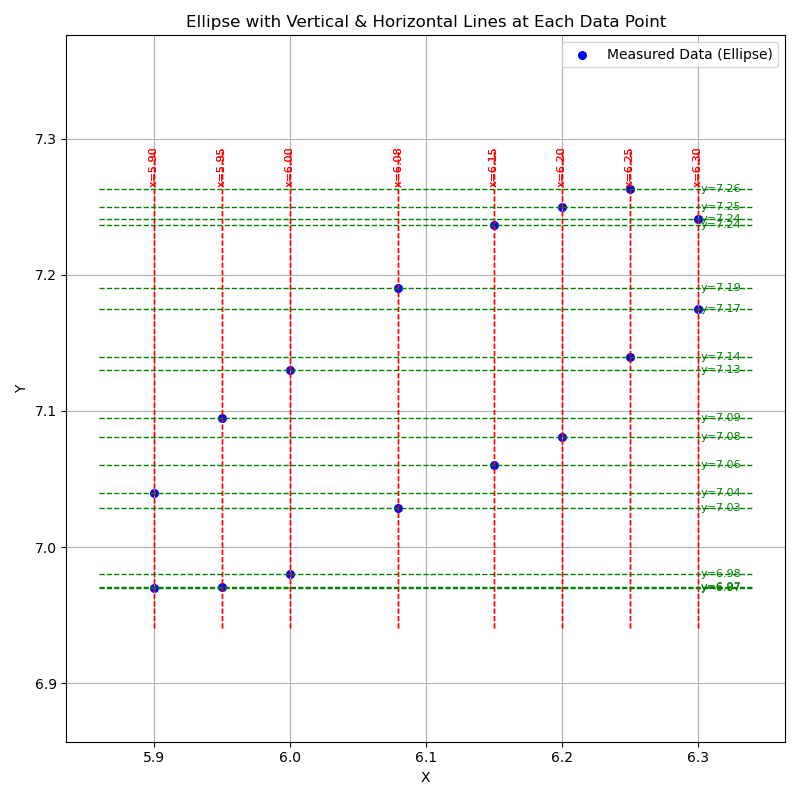

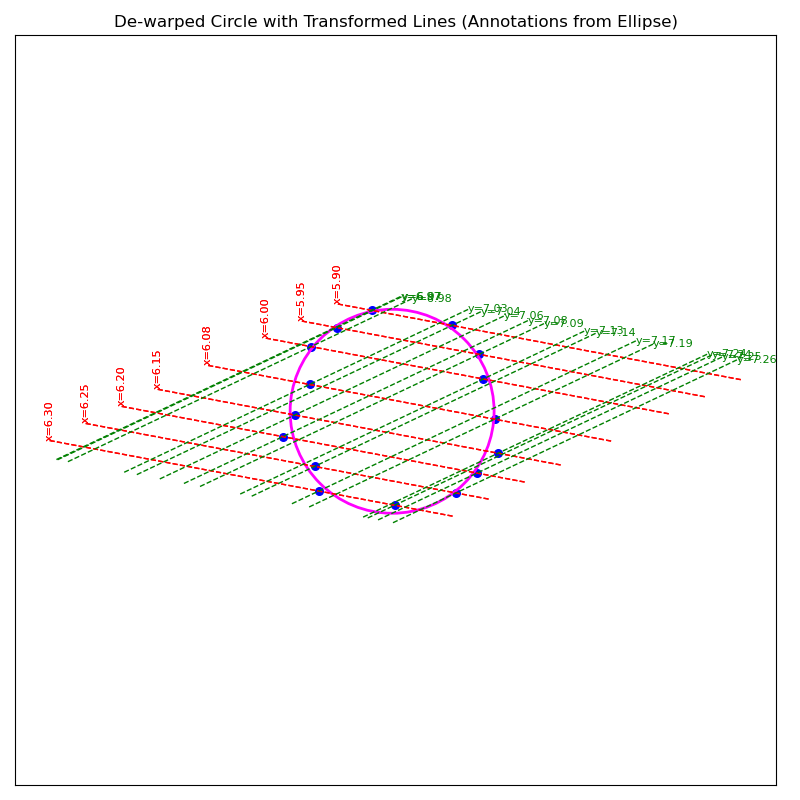

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA (ELLIPSE) HERE
# =====================================================
# Replace the [...] with your measured data.
# Example:
#    x_data = np.array([1.0, 2.0, 3.0, ...])
#    y_data = np.array([4.0, 5.0, 6.0, ...])
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE DE-WARPING TRANSFORMATION VIA OPTIMIZATION
# =====================================================
# We assume that the measured ellipse can be de-warped to a circle by:
#   - Centering the data,
#   - Rotating by an angle (theta),
#   - Applying an affine mapping with shear (c) and scaling (b) in one direction.
#
# Transformation:
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at 0,0), we require:
#       sqrt((x')^2 + (y')^2) = r
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# Initial guess for parameters:
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized de-warping parameters:")
print("  b (scaling for v):", b_opt)
print("  c (shear):", c_opt)
print("  theta (radians):", theta_opt)
print("  r (circle radius):", r_opt)

# =====================================================
# 3. HELPER FUNCTION TO APPLY THE TRANSFORMATION
# =====================================================
def transform_points(x, y, xm, ym, theta, c, b):
    """
    Given arrays x and y, subtract the centroid (xm, ym), rotate by theta,
    and apply the affine transformation (shear c and scaling b) to yield (x', y').
    """
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return x_prime, y_prime

# Transform the measured data to de-warped (circle) coordinates.
x_prime, y_prime = transform_points(x_data, y_data, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 4. CREATE VERTICAL & HORIZONTAL LINES AT EACH DATA POINT (ELLIPSE)
# =====================================================
# Determine the data range and add some padding.
x_min, x_max = np.min(x_data), np.max(x_data)
y_min, y_max = np.min(y_data), np.max(y_data)
pad_x = 0.1 * (x_max - x_min)
pad_y = 0.1 * (y_max - y_min)

num_line_points = 200  # number of sample points for each line

# Create lists to hold line data for the ellipse and their transformed counterparts.
vertical_lines_ellipse = []      # Each element is a tuple: (x_line, y_line)
vertical_lines_transformed = []  # Transformed vertical lines
horizontal_lines_ellipse = []    # Each element is a tuple: (x_line, y_line)
horizontal_lines_transformed = []  # Transformed horizontal lines

# For every measured x-value, create a vertical line (x fixed, y varying)
for x_val in x_data:
    y_line = np.linspace(y_min - pad_y, y_max + pad_y, num_line_points)
    x_line = np.full_like(y_line, x_val)
    vertical_lines_ellipse.append((x_line, y_line))
    # Transform the vertical line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    vertical_lines_transformed.append((x_line_t, y_line_t))

# For every measured y-value, create a horizontal line (y fixed, x varying)
for y_val in y_data:
    x_line = np.linspace(x_min - pad_x, x_max + pad_x, num_line_points)
    y_line = np.full_like(x_line, y_val)
    horizontal_lines_ellipse.append((x_line, y_line))
    # Transform the horizontal line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    horizontal_lines_transformed.append((x_line_t, y_line_t))

# =====================================================
# 5. PLOT FIGURE 1: THE ORIGINAL ELLIPSE WITH VERTICAL & HORIZONTAL LINES
# =====================================================
plt.figure(figsize=(8, 8))
plt.scatter(x_data, y_data, color='blue', s=30, label='Measured Data (Ellipse)')

# Plot and annotate vertical lines.
for (x_line, y_line) in vertical_lines_ellipse:
    plt.plot(x_line, y_line, 'r--', linewidth=1)
    # Annotate at the top of the line.
    x_val = x_line[0]
    plt.text(x_val, y_max + pad_y * 0.05, f"x={x_val:.2f}",
             rotation=90, color='red', fontsize=8, ha='center', va='bottom')

# Plot and annotate horizontal lines.
for (x_line, y_line) in horizontal_lines_ellipse:
    plt.plot(x_line, y_line, 'g--', linewidth=1)
    # Annotate near the right end of the line.
    y_val = y_line[0]
    plt.text(x_max + pad_x * 0.05, y_val, f"y={y_val:.2f}",
             color='green', fontsize=8, ha='left', va='center')

plt.title("Ellipse with Vertical & Horizontal Lines at Each Data Point")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 6. PLOT FIGURE 2: THE DE-WARPED CIRCLE WITH TRANSFORMED LINES (NO TICKS OR AXIS LABELS)
# =====================================================
plt.figure(figsize=(8, 8))
plt.scatter(x_prime, y_prime, color='blue', s=30, label='De-warped Data (Circle)')

# Draw the fitted circle.
circle = plt.Circle((0, 0), r_opt, color='magenta', fill=False, lw=2, label='Fitted Circle')
plt.gca().add_patch(circle)

# Plot and annotate transformed vertical lines.
for idx, (x_line_t, y_line_t) in enumerate(vertical_lines_transformed):
    plt.plot(x_line_t, y_line_t, 'r--', linewidth=1)
    # Use the original x value for annotation.
    x_orig = x_data[idx]
    # Choose a representative point for annotation: use the top of the transformed line.
    plt.text(x_line_t[0], max(y_line_t), f"x={x_orig:.2f}",
             rotation=90, color='red', fontsize=8, ha='center', va='bottom')

# Plot and annotate transformed horizontal lines.
for idx, (x_line_t, y_line_t) in enumerate(horizontal_lines_transformed):
    plt.plot(x_line_t, y_line_t, 'g--', linewidth=1)
    # Use the original y value for annotation.
    y_orig = y_data[idx]
    # Choose a representative point for annotation: use the right end of the transformed line.
    plt.text(max(x_line_t), y_line_t[0], f"y={y_orig:.2f}",
             color='green', fontsize=8, ha='left', va='center')

# Remove all x and y ticks and labels.
ax_circle = plt.gca()
ax_circle.set_xticks([])
ax_circle.set_yticks([])
ax_circle.set_xlabel('')
ax_circle.set_ylabel('')

plt.title("De-warped Circle with Transformed Lines (Annotations from Ellipse)")
plt.axis('equal')
plt.grid(False)
plt.tight_layout()
plt.show()


Optimized de-warping parameters:
  b (scaling for v): 3.3591945050598135
  c (shear): -0.003289458933792583
  theta (radians): 99081.68348272817
  r (circle radius): 0.07520428214059806


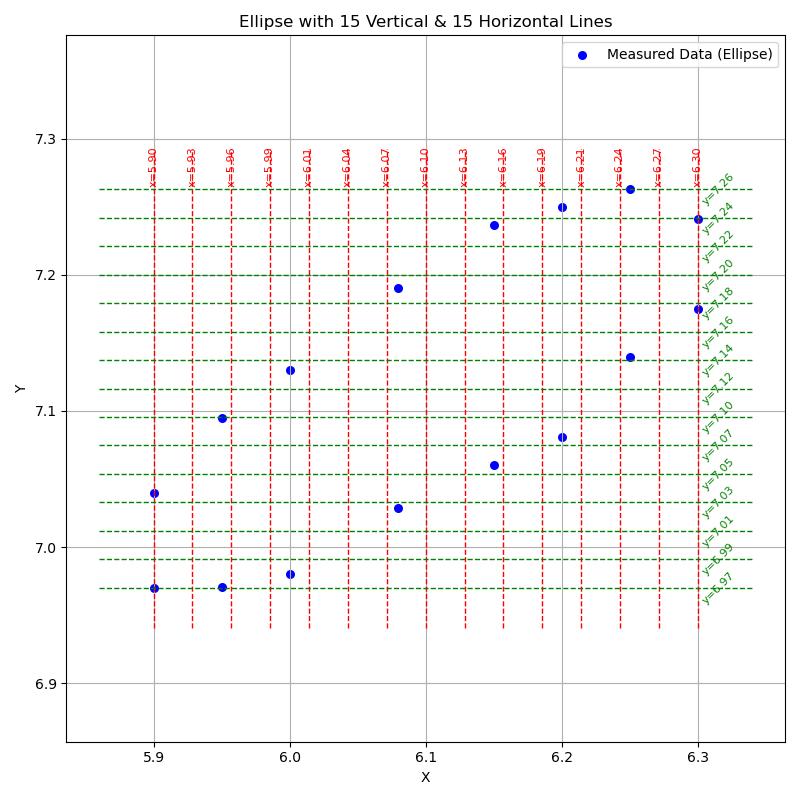

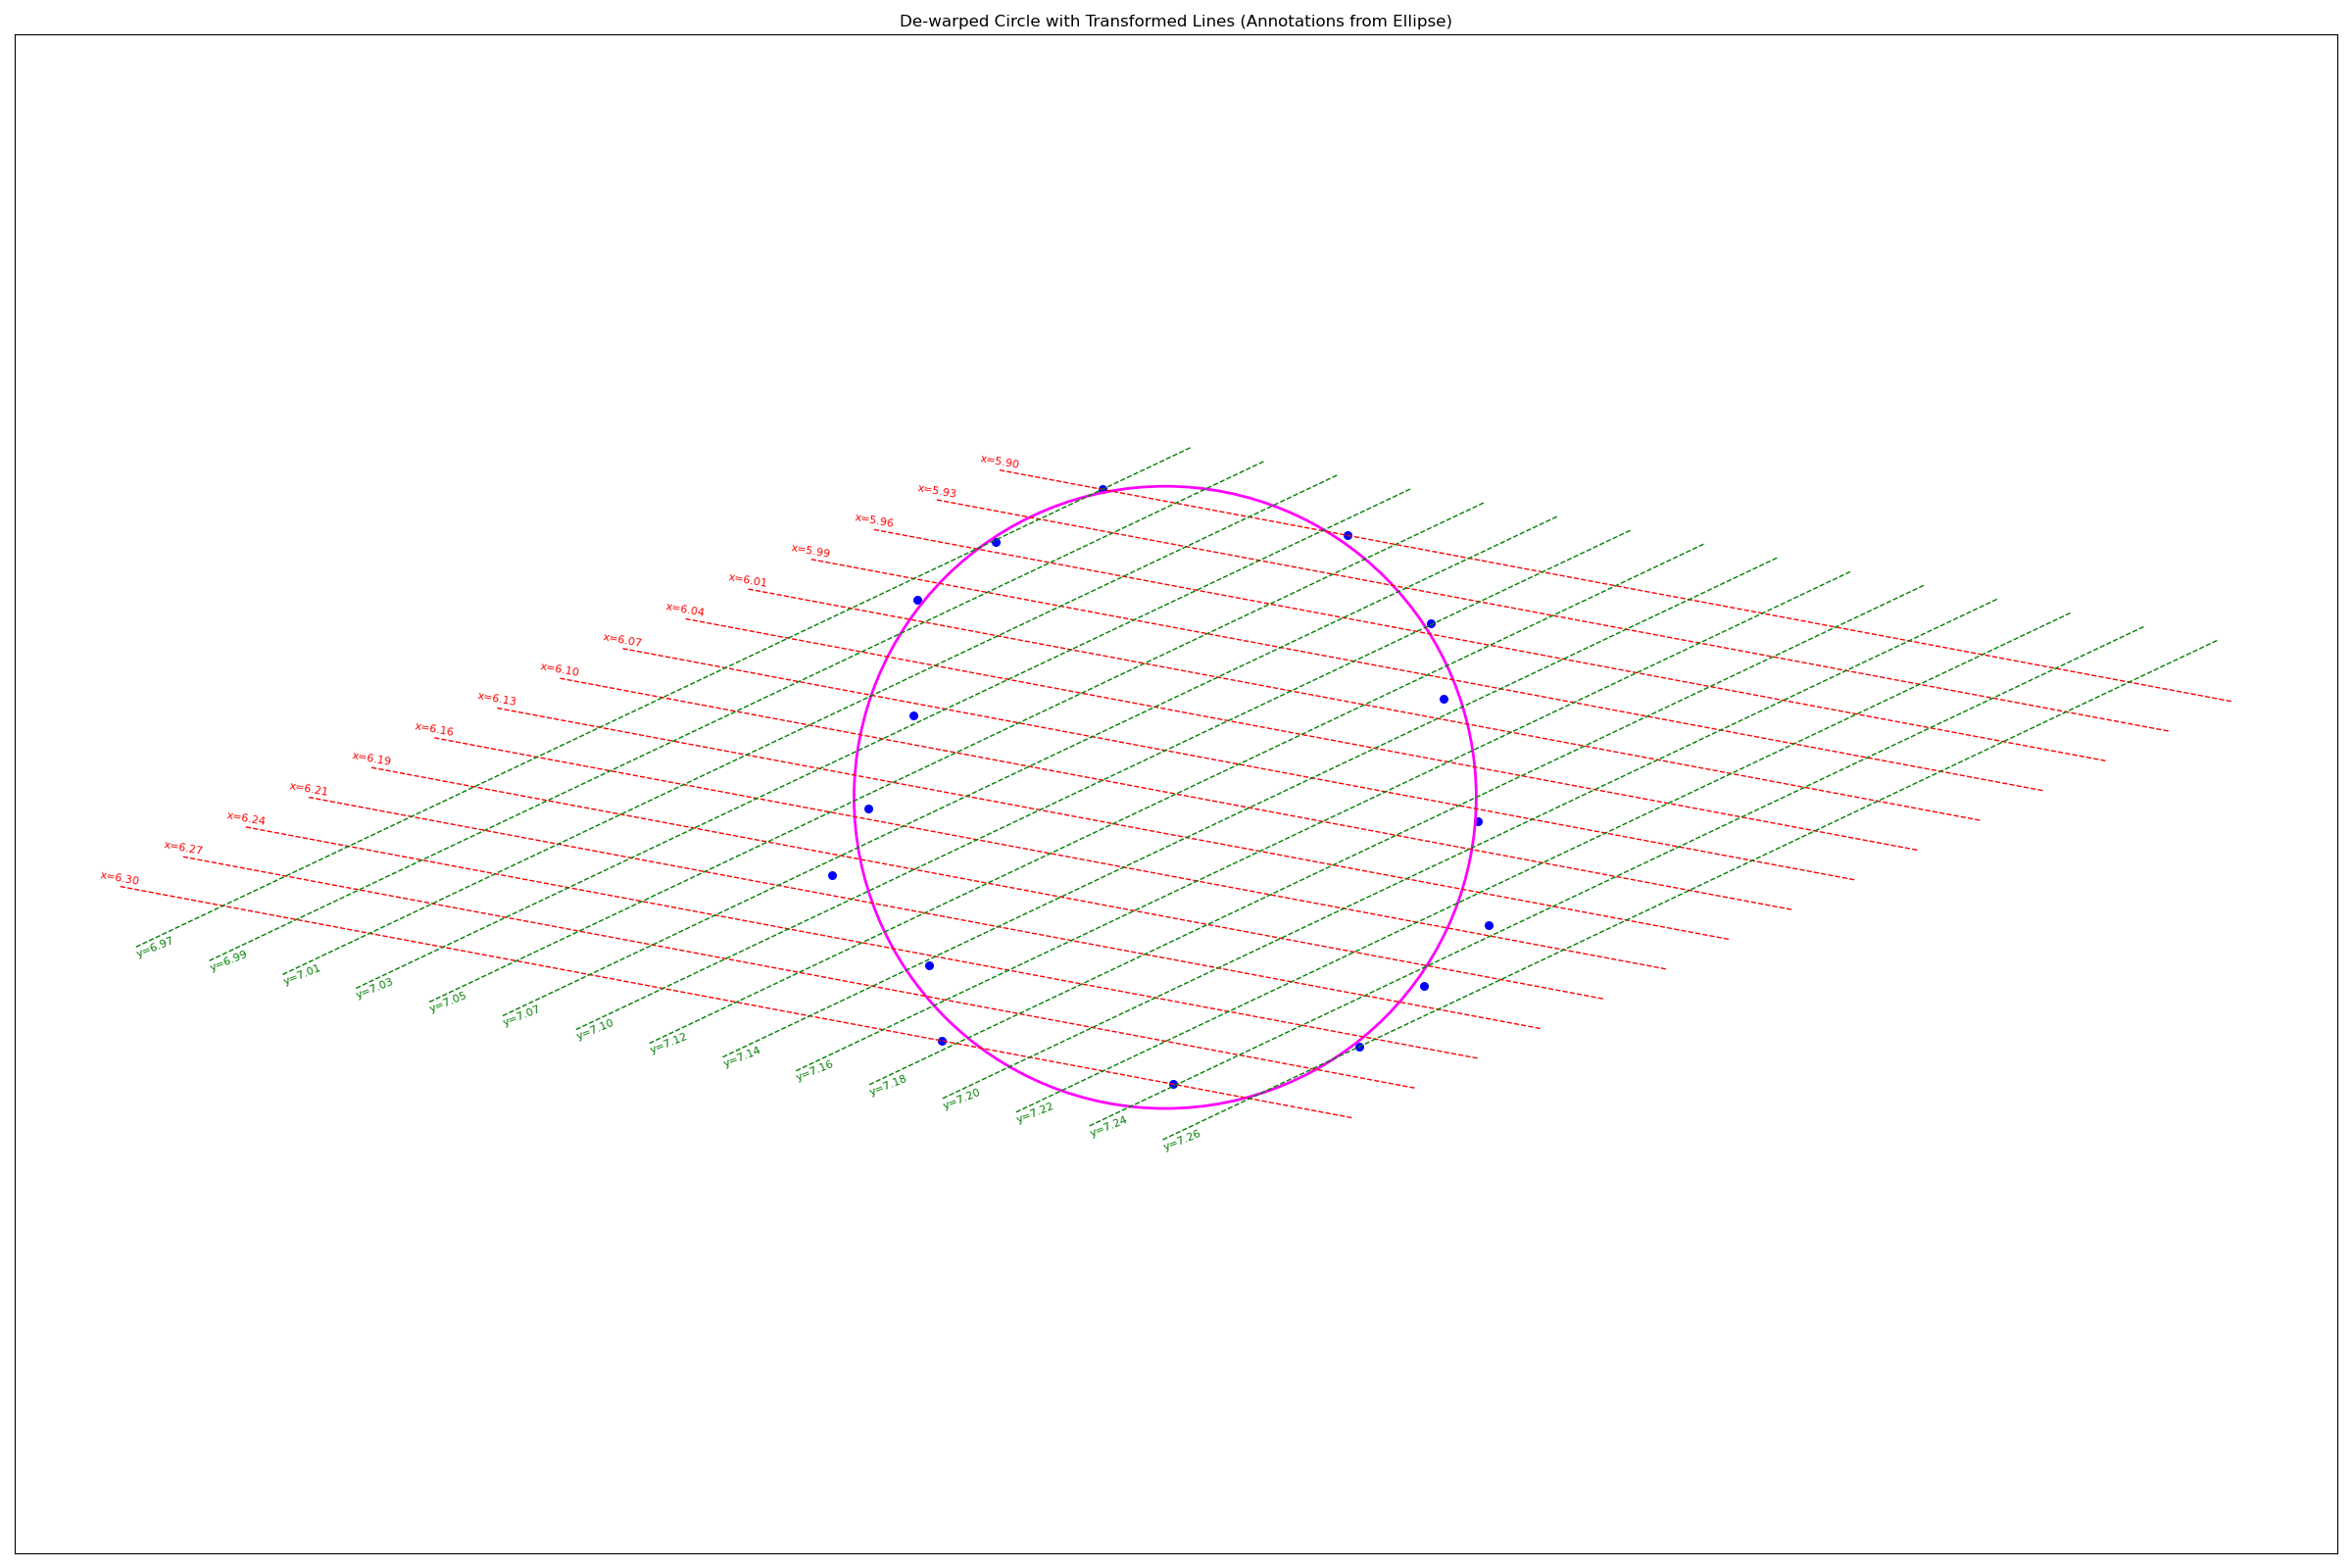

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# =====================================================
# 1. INPUT YOUR MEASURED DATA (ELLIPSE) HERE
# =====================================================
# Replace the [...] with your measured data.
# For example:
x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE DE-WARPING TRANSFORMATION VIA OPTIMIZATION
# =====================================================
# We assume the measured ellipse can be de-warped to a circle by:
#   - Centering the data,
#   - Rotating by an angle (theta),
#   - Applying an affine transformation with a shear (c) and scaling (b) in one direction.
#
# The transformation is defined as:
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at 0,0), we require:
#       sqrt((x')^2 + (y')^2) = r
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# Initial guess for parameters:
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized de-warping parameters:")
print("  b (scaling for v):", b_opt)
print("  c (shear):", c_opt)
print("  theta (radians):", theta_opt)
print("  r (circle radius):", r_opt)

# =====================================================
# 3. HELPER FUNCTION TO APPLY THE TRANSFORMATION
# =====================================================
def transform_points(x, y, xm, ym, theta, c, b):
    """
    Given arrays x and y, subtract the centroid (xm, ym), rotate by theta,
    and apply the affine transformation (shear c and scaling b) to yield (x', y').
    """
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return x_prime, y_prime

# Transform the measured data to de-warped (circle) coordinates.
x_prime, y_prime = transform_points(x_data, y_data, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 4. CREATE VERTICAL & HORIZONTAL LINES BASED ON THE DATA RANGE
# =====================================================
# We'll create 15 vertical lines evenly spaced between min(x_data) and max(x_data)
# and 15 horizontal lines evenly spaced between min(y_data) and max(y_data).

num_lines = 15

# Determine the data range and add some padding.
x_min, x_max = np.min(x_data), np.max(x_data)
y_min, y_max = np.min(y_data), np.max(y_data)
pad_x = 0.1 * (x_max - x_min)
pad_y = 0.1 * (y_max - y_min)

# Generate 15 evenly spaced x values for vertical lines and y values for horizontal lines.
vertical_xs = np.linspace(x_min, x_max, num_lines)
horizontal_ys = np.linspace(y_min, y_max, num_lines)

num_line_points = 200  # number of sample points for each line

# Create lists to hold line data for the ellipse and their transformed counterparts.
vertical_lines_ellipse = []      # Each element: (x_line, y_line)
vertical_lines_transformed = []  # Transformed vertical lines
horizontal_lines_ellipse = []    # Each element: (x_line, y_line)
horizontal_lines_transformed = []  # Transformed horizontal lines

# For each vertical line (constant x), let y vary.
for x_val in vertical_xs:
    y_line = np.linspace(y_min - pad_y, y_max + pad_y, num_line_points)
    x_line = np.full_like(y_line, x_val)
    vertical_lines_ellipse.append((x_line, y_line))
    # Transform the vertical line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    vertical_lines_transformed.append((x_line_t, y_line_t))

# For each horizontal line (constant y), let x vary.
for y_val in horizontal_ys:
    x_line = np.linspace(x_min - pad_x, x_max + pad_x, num_line_points)
    y_line = np.full_like(x_line, y_val)
    horizontal_lines_ellipse.append((x_line, y_line))
    # Transform the horizontal line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    horizontal_lines_transformed.append((x_line_t, y_line_t))

# =====================================================
# 5. PLOT FIGURE 1: THE ORIGINAL ELLIPSE WITH LINES
# =====================================================
plt.figure(figsize=(8, 8))
plt.scatter(x_data, y_data, color='blue', s=30, label='Measured Data (Ellipse)')

# Plot and annotate vertical lines (red dashed).
for (x_line, y_line) in vertical_lines_ellipse:
    plt.plot(x_line, y_line, 'r--', linewidth=1)
    # Annotate at the top of the line.
    x_val = x_line[0]
    plt.text(x_val, y_max + pad_y * 0.05, f"x={x_val:.2f}",
             rotation=90, color='red', fontsize=8, ha='center', va='bottom')

# Plot and annotate horizontal lines (green dashed).
for (x_line, y_line) in horizontal_lines_ellipse:
    plt.plot(x_line, y_line, 'g--', linewidth=1)
    # Annotate near the right end of the line.
    y_val = y_line[0]
    plt.text(x_max + pad_x * 0.05, y_val, f"y={y_val:.2f}", rotation = 45,
             color='green', fontsize=8, ha='left', va='center')

plt.title("Ellipse with 15 Vertical & 15 Horizontal Lines")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 6. PLOT FIGURE 2: THE DE-WARPED CIRCLE WITH TRANSFORMED LINES
# =====================================================
plt.figure(figsize=(24, 16))
plt.scatter(x_prime, y_prime, color='blue', s=30, label='De-warped Data (Circle)')

# Draw the fitted circle (centered at (0,0) in de-warped coordinates).
circle = plt.Circle((0, 0), r_opt, color='magenta', fill=False, lw=2, label='Fitted Circle')
plt.gca().add_patch(circle)

# Plot and annotate transformed vertical lines.
for idx, (x_line_t, y_line_t) in enumerate(vertical_lines_transformed):
    plt.plot(x_line_t, y_line_t, 'r--', linewidth=1)
    # Annotate at the top of the transformed vertical line.
    orig_x = vertical_xs[idx]
    plt.text(x_line_t[0], np.max(y_line_t), f"x={orig_x:.2f}",
             rotation=-10, color='red', fontsize=8, ha='center', va='bottom')

# Plot and annotate transformed horizontal lines.
for idx, (x_line_t, y_line_t) in enumerate(horizontal_lines_transformed):
    plt.plot(x_line_t, y_line_t, 'g--', linewidth=1)
    # Annotate near the right end of the transformed horizontal line.
    orig_y = horizontal_ys[idx]
    plt.text(np.min(x_line_t), y_line_t[-1], f"y={orig_y:.2f}",rotation = 22,
             color='green', fontsize=8, ha='left', va='center')

# Remove all x and y ticks and labels.
ax_circle = plt.gca()
ax_circle.set_xticks([])
ax_circle.set_yticks([])
ax_circle.set_xlabel('')
ax_circle.set_ylabel('')

plt.title("De-warped Circle with Transformed Lines (Annotations from Ellipse)")
plt.axis('equal')
plt.grid(False)
plt.tight_layout()
plt.show()


Optimized de‑warping parameters:
  b (scaling for v): 3.854165851858959
  c (shear): -0.009739254347381763
  theta (radians): 585736.3627098313
  r (circle radius): 0.06932500508328168


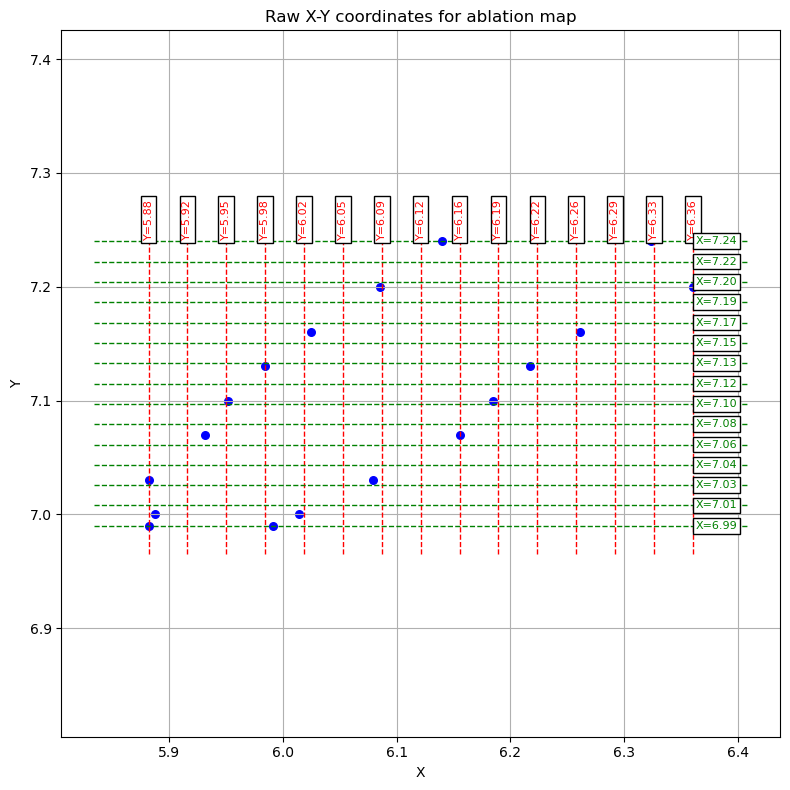

[[7.07  6.065]
 [7.2   6.188]]


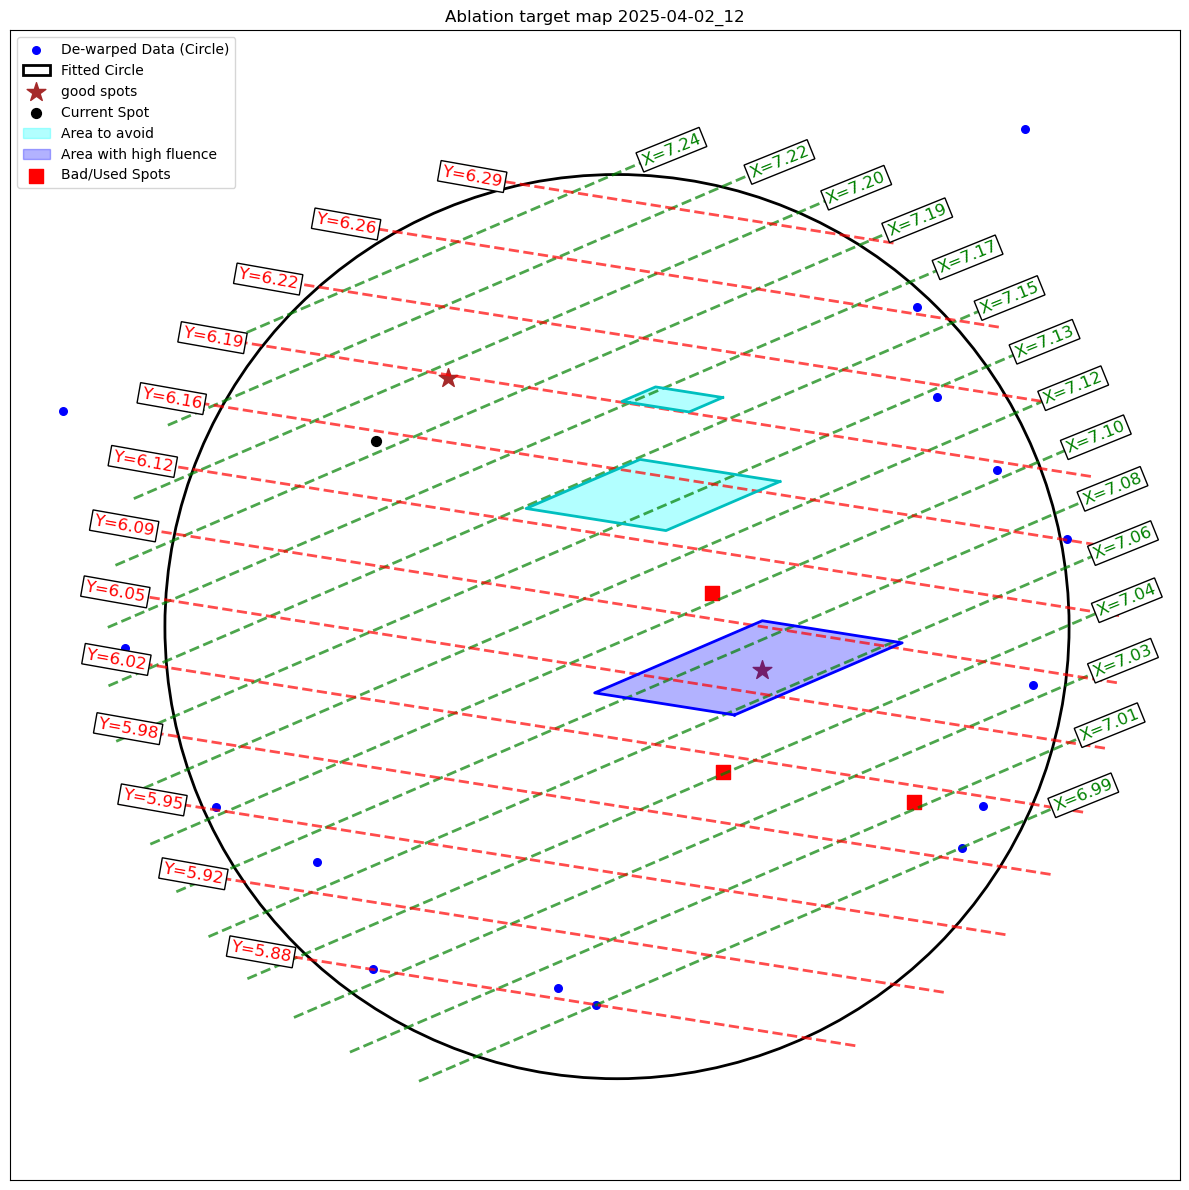

<Figure size 640x480 with 0 Axes>

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
import datetime
# =====================================================
# 1. INPUT YOUR MEASURED DATA (ELLIPSE) HERE
# =====================================================

x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])
x_data = np.array([6.156,5.932,5.952,6.185,6.2613,6.025,6.085,6.3603,6.3233,6.1401,6.079,5.882,5.882,5.991,6.014,5.88736,6.2172,5.9845])
y_data = np.array([7.07,7.07,7.10,7.10,7.16,7.16,7.20,7.20,7.24,7.24,7.03,7.03,6.99,6.99,7.00,7.00,7.13,7.13])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE DE-WARPING TRANSFORMATION VIA OPTIMIZATION
# =====================================================
# We assume that the measured ellipse can be de‑warped to a circle by:
#   - Centering the data,
#   - Rotating by an angle (theta),
#   - Applying an affine transformation with shear (c) and scaling (b) in one direction.
#
# The transformation is:
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at 0,0), we require:
#       sqrt((x')^2 + (y')^2) = r
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# Initial guess for parameters:
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized de‑warping parameters:")
print("  b (scaling for v):", b_opt)
print("  c (shear):", c_opt)
print("  theta (radians):", theta_opt)
print("  r (circle radius):", r_opt)

# =====================================================
# 3. HELPER FUNCTION TO APPLY THE TRANSFORMATION
# =====================================================
def transform_points(x, y, xm, ym, theta, c, b):
    """
    Given arrays x and y, subtract the centroid (xm, ym), rotate by theta,
    and apply the affine transformation (shear c and scaling b) to yield (x', y').
    """
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return x_prime, y_prime

# Transform the measured data to de‑warped (circle) coordinates.
x_prime, y_prime = transform_points(x_data, y_data, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 4. CREATE 15 VERTICAL & 15 HORIZONTAL LINES BASED ON THE DATA RANGE
# =====================================================
num_lines = 15

# Determine the data range (from the ellipse) and add some padding.
x_min, x_max = np.min(x_data), np.max(x_data)
y_min, y_max = np.min(y_data), np.max(y_data)
pad_x = 0.1 * (x_max - x_min)
pad_y = 0.1 * (y_max - y_min)

# Generate 15 evenly spaced x-values (for vertical lines) and y-values (for horizontal lines)
vertical_xs = np.linspace(x_min, x_max, num_lines)
horizontal_ys = np.linspace(y_min, y_max, num_lines)

num_line_points = 200  # number of sample points per line

# Create lists to hold line data (in the ellipse coordinate system) and their transformed versions.
vertical_lines_ellipse = []      # Each element: (x_line, y_line)
vertical_lines_transformed = []  # Each element: (x_line_trans, y_line_trans)
horizontal_lines_ellipse = []    # Each element: (x_line, y_line)
horizontal_lines_transformed = []  # Each element: (x_line_trans, y_line_trans)

# For each vertical line (constant x), let y vary over the padded range.
for x_val in vertical_xs:
    y_line = np.linspace(y_min - pad_y, y_max + pad_y, num_line_points)
    x_line = np.full_like(y_line, x_val)
    vertical_lines_ellipse.append((x_line, y_line))
    # Transform the line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    vertical_lines_transformed.append((x_line_t, y_line_t))

# For each horizontal line (constant y), let x vary.
for y_val in horizontal_ys:
    x_line = np.linspace(x_min - pad_x, x_max + pad_x, num_line_points)
    y_line = np.full_like(x_line, y_val)
    horizontal_lines_ellipse.append((x_line, y_line))
    # Transform the line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    horizontal_lines_transformed.append((x_line_t, y_line_t))

def clip_line_to_circle(x_line, y_line, r, extend_fraction=0.1):
    """
    Given a transformed line (arrays x_line and y_line) that lies along a straight line,
    compute the intersection (chord) of its infinite extension with the circle of radius r
    centered at (0,0), then extend that chord by a fraction (extend_fraction) on each end.
    Returns two points [x_start, x_end] and [y_start, y_end] for plotting the line segment.
    """
    # Use the endpoints of the sampled line as a representation.
    p0 = np.array([x_line[0], y_line[0]])
    p1 = np.array([x_line[-1], y_line[-1]])
    d = p1 - p0
    A = np.dot(d, d)
    B = 2 * np.dot(p0, d)
    C = np.dot(p0, p0) - r**2
    disc = B**2 - 4*A*C
    if disc < 0:
        # No real intersection; return an empty segment.
        return None, None
    sqrt_disc = np.sqrt(disc)
    t1 = (-B - sqrt_disc) / (2 * A)
    t2 = (-B + sqrt_disc) / (2 * A)
    # Ensure t1 < t2.
    if t1 > t2:
        t1, t2 = t2, t1
    chord_length = t2 - t1
    # Extend the chord by the given fraction on each side.
    t1_ext = t1 - extend_fraction * 0.3#chord_length
    t2_ext = t2 + extend_fraction * 0.3#chord_length
    p_start = p0 + t1_ext * d
    p_end   = p0 + t2_ext * d
    return p_start, p_end

plt.figure(figsize=(8, 8))

# Plot and annotate vertical lines (full-length).
for (x_line, y_line) in vertical_lines_ellipse:
    plt.plot(x_line, y_line, 'r--', linewidth=1)
    # Annotate at the top of the line.
    x_val = x_line[0]
    plt.text(x_val, y_max + pad_y * 0.05, f"Y={x_val:.2f}",
             rotation=90, color='red', fontsize=8, ha='center', va='bottom',bbox=dict(facecolor='white', edgecolor='black', pad=2))

# Plot and annotate horizontal lines (full-length).
for (x_line, y_line) in horizontal_lines_ellipse:
    plt.plot(x_line, y_line, 'g--', linewidth=1)
    # Annotate near the right end of the line.
    y_val = y_line[0]
    plt.text(x_max + pad_x * 0.05, y_val, f"X={y_val:.2f}",
             color='green', fontsize=8, ha='left', va='center',bbox=dict(facecolor='white', edgecolor='black', pad=2))
plt.scatter(x_data, y_data, color='blue', s=30, label='Measured Data (Ellipse)')
plt.title("Raw X-Y coordinates for ablation map")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
# plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 12))
plt.scatter(x_prime, y_prime, color='blue', s=30, label='De‑warped Data (Circle)')

# Draw the fitted circle (centered at (0,0) in de‑warped coordinates).
circle = plt.Circle((0, 0), r_opt, color='black', fill=False, lw=2, label='Fitted Circle')
plt.gca().add_patch(circle)
# For each transformed horizontal line, clip it to the circle and plot.
for idx, (x_line_t, y_line_t) in enumerate(horizontal_lines_transformed):
    p_start, p_end = clip_line_to_circle(x_line_t, y_line_t, r_opt, extend_fraction=0.1)
    if p_start is not None and p_end is not None:
        plt.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]], 'g--', linewidth=2,alpha = 0.7)
        # Annotate near the right end (use p_end and the original horizontal y value).
        orig_y = horizontal_ys[idx]
        plt.text(p_end[0], p_end[1], f"X={orig_y:.2f}",rotation = 22, 
                 color='green', fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='black', pad=2))
# For each transformed vertical line, clip it to the circle and plot.
for idx, (x_line_t, y_line_t) in enumerate(vertical_lines_transformed):
    p_start, p_end = clip_line_to_circle(x_line_t, y_line_t, r_opt, extend_fraction=0.1)
    if p_start is not None and p_end is not None:
        plt.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]], 'r--', linewidth=2,alpha = 0.7)
        # plt.scatter(p_start[0], p_start[1])
        # Annotate at the top (use p_start and the original vertical x value).
        orig_x = vertical_xs[idx]
        plt.text(p_end[0], p_end[1], f"Y={orig_x:.2f}",
                 rotation=-10, color='red', fontsize=12, ha='center', va='center',bbox=dict(facecolor='white', edgecolor='black', pad=2))

bad_spots_y_e = np.array([7.01, 7.044])
bad_spots_x_e = np.array([6.01,6.01])
bad_spots_x_circle, bad_spots_y_circle = transform_points(
    np.array([bad_spots_x_e]), np.array([bad_spots_y_e]),
    xm, ym, theta_opt, c_opt, b_opt
)

filename_good = r"Z:\Lab Data\Target Map\list_of_good_spots.txt"

data_good = np.loadtxt(filename_good,delimiter=',')

current_y_ellipse = data_good[:,0]
current_x_ellipse = data_good[:,1]
print(data_good)

current_x_circle, current_y_circle = transform_points(
    np.array([current_x_ellipse]), np.array([current_y_ellipse]),
    xm, ym, theta_opt, c_opt, b_opt
)
plt.scatter(current_x_circle, current_y_circle, marker='*', color='brown', s=200, label='good spots')

current_x_ellipse = 6.15
current_y_ellipse = 7.19
current_x_circle, current_y_circle = transform_points(
    np.array([current_x_ellipse]), np.array([current_y_ellipse]),
    xm, ym, theta_opt, c_opt, b_opt
)
plt.scatter(current_x_circle, current_y_circle, marker='o', color='black', s=50, label='Current Spot')


filename_bad = r"Z:\Lab Data\Target Map\list_of_bad_spots.txt"

# Load the data from the file; each line is "y,x".
data_bad = np.loadtxt(filename_bad, delimiter=',')

# The first column is y values, the second column is x values
bad_spots_y_e = data_bad[:, 0]
bad_spots_x_e = data_bad[:, 1]
# Now pass these arrays into transform_points as before
bad_spots_x_circle, bad_spots_y_circle = transform_points(
    np.array([bad_spots_x_e]), 
    np.array([bad_spots_y_e]),
    xm, ym, theta_opt, c_opt, b_opt
)

polygon_x_ellipse = np.array([6.162, 6.128, 6.128, 6.162])
polygon_y_ellipse = np.array([7.125, 7.125, 7.15, 7.15])
# Transform polygon vertices to circle coordinates.
polygon_x_circle, polygon_y_circle = transform_points(
    polygon_x_ellipse, polygon_y_ellipse, xm, ym, theta_opt, c_opt, b_opt
)
# Close the polygon by appending the first vertex to the end.
polygon_x_circle = np.append(polygon_x_circle, polygon_x_circle[0])
polygon_y_circle = np.append(polygon_y_circle, polygon_y_circle[0])
# Plot the polygon.
plt.plot(polygon_x_circle, polygon_y_circle, 'c-', lw=2)
plt.fill(polygon_x_circle, polygon_y_circle, color='cyan', alpha=0.3, label='Area to avoid')

polygon_x_ellipse = np.array([6.2, 6.19, 6.19, 6.2])
polygon_y_ellipse = np.array([7.158, 7.158, 7.17, 7.17])
# Transform polygon vertices to circle coordinates.
polygon_x_circle, polygon_y_circle = transform_points(
    polygon_x_ellipse, polygon_y_ellipse, xm, ym, theta_opt, c_opt, b_opt
)
# Close the polygon by appending the first vertex to the end.
polygon_x_circle = np.append(polygon_x_circle, polygon_x_circle[0])
polygon_y_circle = np.append(polygon_y_circle, polygon_y_circle[0])
# Plot the polygon.
plt.plot(polygon_x_circle, polygon_y_circle, 'c-', lw=2)
plt.fill(polygon_x_circle, polygon_y_circle, color='cyan', alpha=0.3)

polygon_x_ellipse = np.array([6.04, 6.09, 6.09, 6.04])
polygon_y_ellipse = np.array([7.06, 7.06, 7.085, 7.085])
# Transform polygon vertices to circle coordinates.
polygon_x_circle, polygon_y_circle = transform_points(
    polygon_x_ellipse, polygon_y_ellipse, xm, ym, theta_opt, c_opt, b_opt
)
# Close the polygon by appending the first vertex to the end.
polygon_x_circle = np.append(polygon_x_circle, polygon_x_circle[0])
polygon_y_circle = np.append(polygon_y_circle, polygon_y_circle[0])
# Plot the polygon.
plt.plot(polygon_x_circle, polygon_y_circle, 'b-', lw=2)
plt.fill(polygon_x_circle, polygon_y_circle, color='blue', alpha=0.3, label = 'Area with high fluence')

plt.scatter(bad_spots_x_circle, bad_spots_y_circle, marker='s', color='red', s=100, label='Bad/Used Spots')

# Remove x and y ticks/labels.
ax_circle = plt.gca()
ax_circle.set_xticks([])
ax_circle.set_yticks([])
ax_circle.set_xlabel('')
ax_circle.set_ylabel('')


dt_string = datetime.datetime.now().strftime("%Y-%m-%d_%H")

plt.title(f"Ablation target map {dt_string}")
plt.axis('equal')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig(f'Z:\Lab Data\Target Map\Ablation_Target_map_{dt_string}',dpi = 800)

In [23]:
%matplotlib widget

Optimized de‑warping parameters:
  b (scaling for v): 3.6611361452876894
  c (shear): -0.00576760651992593
  theta (radians): 1523372.9376944804
  r (circle radius): 0.06563675995447607


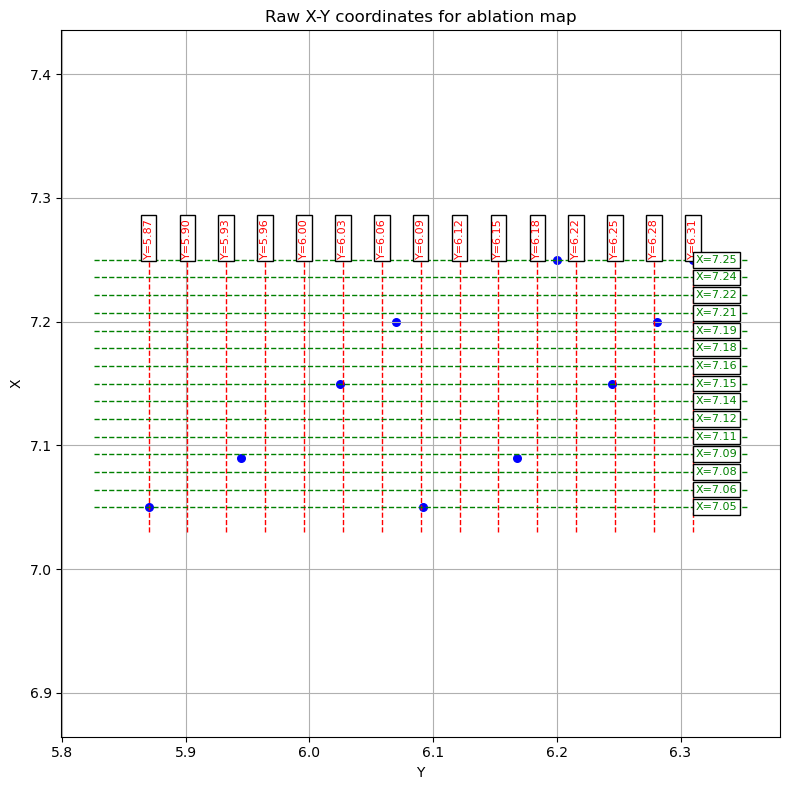

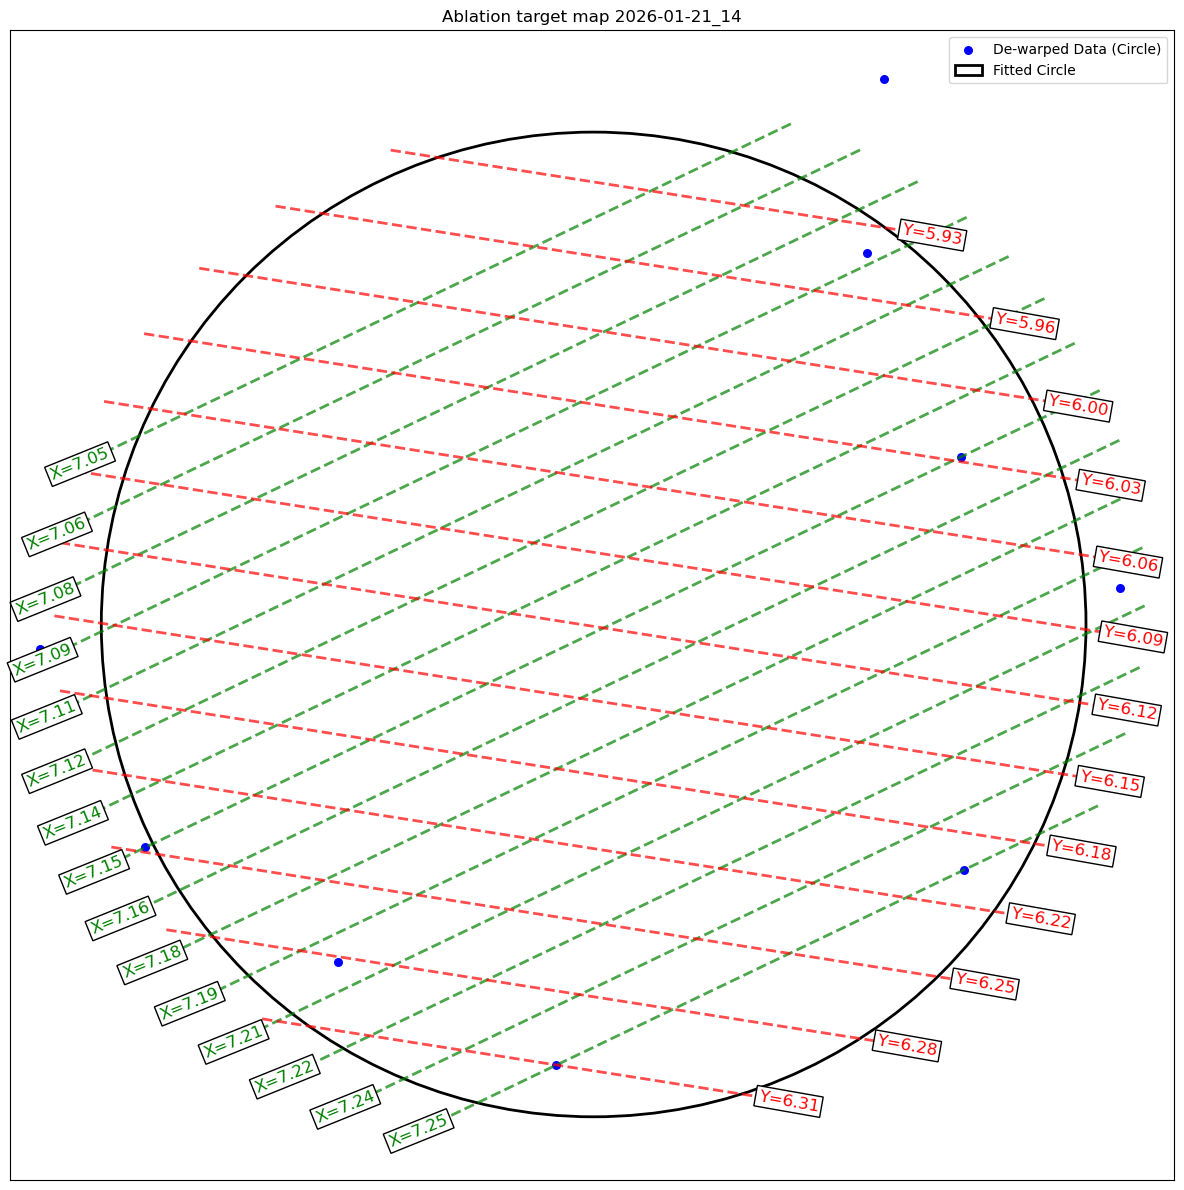

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
import datetime
# =====================================================
# 1. INPUT YOUR MEASURED DATA (ELLIPSE) HERE
# =====================================================

# x_data = np.array([6.25,6.25,6.2,6.2,6.08,6.08,6.0,6, 5.95,5.95,5.9,5.9,6.15,6.15,6.3,6.3])
# y_data = np.array([7.14,7.263,7.081,7.25,7.029,7.19,6.98,7.13,6.971,7.095,6.97,7.04,7.06,7.237,7.241,7.175])

# x_data = np.array([6.156,5.932,5.952,6.185,6.2613,6.025,6.085,6.3603,6.3233,6.1401,6.079,5.882,5.882,5.991,6.014,5.88736,6.2172,5.9845])
# y_data = np.array([7.07,7.07,7.10,7.10,7.16,7.16,7.20,7.20,7.24,7.24,7.03,7.03,6.99,6.99,7.00,7.00,7.13,7.13])

# x_data = np.array([7.16118,7.01656,7.01178,7.16190,7.1880,7.03606,7.06888,7.23720,7.24863,7.10148,7.14692,7.26134])
# y_data = np.array([6.037,6.037,6.027,6.027,6.087,6.087,6.137,6.137,6.187,6.187,6.237,6.237])

x_data = np.array([
    6.092, 5.87, 6.168, 5.945, 6.025, 6.245, 6.281, 6.07, 6.20, 6.31
])
y_data = np.array([
    7.05, 7.05, 7.09, 7.09, 7.15, 7.15, 7.2, 7.2, 7.25, 7.25
])

# Compute the centroid (assumed to be the projection of the true circle’s center)
xm = np.mean(x_data)
ym = np.mean(y_data)

# =====================================================
# 2. DEFINE THE DE-WARPING TRANSFORMATION VIA OPTIMIZATION
# =====================================================
# We assume that the measured ellipse can be de‑warped to a circle by:
#   - Centering the data,
#   - Rotating by an angle (theta),
#   - Applying an affine transformation with shear (c) and scaling (b) in one direction.
#
# The transformation is:
#   u = (x - xm)*cos(theta) + (y - ym)*sin(theta)
#   v = -(x - xm)*sin(theta) + (y - ym)*cos(theta)
#   x' = u + c*v
#   y' = v / b
#
# For a perfect circle (centered at 0,0), we require:
#       sqrt((x')^2 + (y')^2) = r
def residuals(params, x, y):
    b, c, theta, r = params
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return np.sqrt(x_prime**2 + y_prime**2) - r

# Initial guess for parameters:
r0 = np.mean(np.sqrt((x_data - xm)**2 + (y_data - ym)**2))
initial_guess = [1.0, 0.0, 0.0, r0]  # [b, c, theta, r]

opt_params, _ = leastsq(residuals, initial_guess, args=(x_data, y_data))
b_opt, c_opt, theta_opt, r_opt = opt_params

print("Optimized de‑warping parameters:")
print("  b (scaling for v):", b_opt)
print("  c (shear):", c_opt)
print("  theta (radians):", theta_opt)
print("  r (circle radius):", r_opt)

# =====================================================
# 3. HELPER FUNCTION TO APPLY THE TRANSFORMATION
# =====================================================
def transform_points(x, y, xm, ym, theta, c, b):
    """
    Given arrays x and y, subtract the centroid (xm, ym), rotate by theta,
    and apply the affine transformation (shear c and scaling b) to yield (x', y').
    """
    dx = x - xm
    dy = y - ym
    u = dx * np.cos(theta) + dy * np.sin(theta)
    v = -dx * np.sin(theta) + dy * np.cos(theta)
    x_prime = u + c * v
    y_prime = v / b
    return x_prime, y_prime

# Transform the measured data to de‑warped (circle) coordinates.
x_prime, y_prime = transform_points(x_data, y_data, xm, ym, theta_opt, c_opt, b_opt)

# =====================================================
# 4. CREATE 15 VERTICAL & 15 HORIZONTAL LINES BASED ON THE DATA RANGE
# =====================================================
num_lines = 15

# Determine the data range (from the ellipse) and add some padding.
x_min, x_max = np.min(x_data), np.max(x_data)
y_min, y_max = np.min(y_data), np.max(y_data)
pad_x = 0.1 * (x_max - x_min)
pad_y = 0.1 * (y_max - y_min)

# Generate 15 evenly spaced x-values (for vertical lines) and y-values (for horizontal lines)
vertical_xs = np.linspace(x_min, x_max, num_lines)
horizontal_ys = np.linspace(y_min, y_max, num_lines)

num_line_points = 200  # number of sample points per line

# Create lists to hold line data (in the ellipse coordinate system) and their transformed versions.
vertical_lines_ellipse = []      # Each element: (x_line, y_line)
vertical_lines_transformed = []  # Each element: (x_line_trans, y_line_trans)
horizontal_lines_ellipse = []    # Each element: (x_line, y_line)
horizontal_lines_transformed = []  # Each element: (x_line_trans, y_line_trans)

# For each vertical line (constant x), let y vary over the padded range.
for x_val in vertical_xs:
    y_line = np.linspace(y_min - pad_y, y_max + pad_y, num_line_points)
    x_line = np.full_like(y_line, x_val)
    vertical_lines_ellipse.append((x_line, y_line))
    # Transform the line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    vertical_lines_transformed.append((x_line_t, y_line_t))

# For each horizontal line (constant y), let x vary.
for y_val in horizontal_ys:
    x_line = np.linspace(x_min - pad_x, x_max + pad_x, num_line_points)
    y_line = np.full_like(x_line, y_val)
    horizontal_lines_ellipse.append((x_line, y_line))
    # Transform the line points.
    x_line_t, y_line_t = transform_points(x_line, y_line, xm, ym, theta_opt, c_opt, b_opt)
    horizontal_lines_transformed.append((x_line_t, y_line_t))

def clip_line_to_circle(x_line, y_line, r, extend_fraction=0.1):
    """
    Given a transformed line (arrays x_line and y_line) that lies along a straight line,
    compute the intersection (chord) of its infinite extension with the circle of radius r
    centered at (0,0), then extend that chord by a fraction (extend_fraction) on each end.
    Returns two points [x_start, x_end] and [y_start, y_end] for plotting the line segment.
    """
    # Use the endpoints of the sampled line as a representation.
    p0 = np.array([x_line[0], y_line[0]])
    p1 = np.array([x_line[-1], y_line[-1]])
    d = p1 - p0
    A = np.dot(d, d)
    B = 2 * np.dot(p0, d)
    C = np.dot(p0, p0) - r**2
    disc = B**2 - 4*A*C
    if disc < 0:
        # No real intersection; return an empty segment.
        return None, None
    sqrt_disc = np.sqrt(disc)
    t1 = (-B - sqrt_disc) / (2 * A)
    t2 = (-B + sqrt_disc) / (2 * A)
    # Ensure t1 < t2.
    if t1 > t2:
        t1, t2 = t2, t1
    chord_length = t2 - t1
    # Extend the chord by the given fraction on each side.
    t1_ext = t1 - extend_fraction * 0.3#chord_length
    t2_ext = t2 + extend_fraction * 0.3#chord_length
    p_start = p0 + t1_ext * d
    p_end   = p0 + t2_ext * d
    return p_start, p_end

plt.figure(figsize=(8, 8))

# Plot and annotate vertical lines (full-length).
for (x_line, y_line) in vertical_lines_ellipse:
    plt.plot(x_line, y_line, 'r--', linewidth=1)
    # Annotate at the top of the line.
    x_val = x_line[0]
    plt.text(x_val, y_max + pad_y * 0.05, f"Y={x_val:.2f}",
             rotation=90, color='red', fontsize=8, ha='center', va='bottom',bbox=dict(facecolor='white', edgecolor='black', pad=2))

# Plot and annotate horizontal lines (full-length).
for (x_line, y_line) in horizontal_lines_ellipse:
    plt.plot(x_line, y_line, 'g--', linewidth=1)
    # Annotate near the right end of the line.
    y_val = y_line[0]
    plt.text(x_max + pad_x * 0.05, y_val, f"X={y_val:.2f}",
             color='green', fontsize=8, ha='left', va='center',bbox=dict(facecolor='white', edgecolor='black', pad=2))
plt.scatter(x_data, y_data, color='blue', s=30, label='Measured Data (Ellipse)')
plt.title("Raw X-Y coordinates for ablation map")
plt.xlabel("Y")
plt.ylabel("X")
plt.axis('equal')
plt.grid(True)
# plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 12))
plt.scatter(x_prime, y_prime, color='blue', s=30, label='De‑warped Data (Circle)')

# Draw the fitted circle (centered at (0,0) in de‑warped coordinates).
circle = plt.Circle((0, 0), r_opt, color='black', fill=False, lw=2, label='Fitted Circle')
plt.gca().add_patch(circle)
# For each transformed horizontal line, clip it to the circle and plot.
for idx, (x_line_t, y_line_t) in enumerate(horizontal_lines_transformed):
    p_start, p_end = clip_line_to_circle(x_line_t, y_line_t, r_opt, extend_fraction=0.1)
    if p_start is not None and p_end is not None:
        plt.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]], 'g--', linewidth=2,alpha = 0.7)
        # Annotate near the right end (use p_end and the original horizontal y value).
        orig_y = horizontal_ys[idx]
        plt.text(p_end[0], p_end[1], f"X={orig_y:.2f}",rotation = 22, 
                 color='green', fontsize=12, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='black', pad=2))
# For each transformed vertical line, clip it to the circle and plot.
for idx, (x_line_t, y_line_t) in enumerate(vertical_lines_transformed):
    p_start, p_end = clip_line_to_circle(x_line_t, y_line_t, r_opt, extend_fraction=0.1)
    if p_start is not None and p_end is not None:
        plt.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]], 'r--', linewidth=2,alpha = 0.7)
        # plt.scatter(p_start[0], p_start[1])
        # Annotate at the top (use p_start and the original vertical x value).
        orig_x = vertical_xs[idx]
        plt.text(p_end[0], p_end[1], f"Y={orig_x:.2f}",
                 rotation=-10, color='red', fontsize=12, ha='center', va='center',bbox=dict(facecolor='white', edgecolor='black', pad=2))

# bad_spots_y_e = np.array([7.01, 7.044])
# bad_spots_x_e = np.array([6.01,6.01])
# bad_spots_x_circle, bad_spots_y_circle = transform_points(
#     np.array([bad_spots_x_e]), np.array([bad_spots_y_e]),
#     xm, ym, theta_opt, c_opt, b_opt
# )

# filename_good = r"Z:\Lab Data\Target Map\list_of_good_spots.txt"

# data_good = np.loadtxt(filename_good,delimiter=',')

# current_y_ellipse = data_good[:,0]
# current_x_ellipse = data_good[:,1]
# print(data_good)

# current_x_circle, current_y_circle = transform_points(
#     np.array([current_x_ellipse]), np.array([current_y_ellipse]),
#     xm, ym, theta_opt, c_opt, b_opt
# )
# plt.scatter(current_x_circle, current_y_circle, marker='*', color='brown', s=200, label='good spots')

# current_x_ellipse = 6.15
# current_y_ellipse = 7.19
# current_x_circle, current_y_circle = transform_points(
#     np.array([current_x_ellipse]), np.array([current_y_ellipse]),
#     xm, ym, theta_opt, c_opt, b_opt
# )
# plt.scatter(current_x_circle, current_y_circle, marker='o', color='black', s=50, label='Current Spot')


# filename_bad = r"Z:\Lab Data\Target Map\list_of_bad_spots.txt"

# # Load the data from the file; each line is "y,x".
# data_bad = np.loadtxt(filename_bad, delimiter=',')

# # The first column is y values, the second column is x values
# bad_spots_y_e = data_bad[:, 0]
# bad_spots_x_e = data_bad[:, 1]
# # Now pass these arrays into transform_points as before
# bad_spots_x_circle, bad_spots_y_circle = transform_points(
#     np.array([bad_spots_x_e]), 
#     np.array([bad_spots_y_e]),
#     xm, ym, theta_opt, c_opt, b_opt
# )

# polygon_x_ellipse = np.array([6.162, 6.128, 6.128, 6.162])
# polygon_y_ellipse = np.array([7.125, 7.125, 7.15, 7.15])
# # Transform polygon vertices to circle coordinates.
# polygon_x_circle, polygon_y_circle = transform_points(
#     polygon_x_ellipse, polygon_y_ellipse, xm, ym, theta_opt, c_opt, b_opt
# )
# # Close the polygon by appending the first vertex to the end.
# polygon_x_circle = np.append(polygon_x_circle, polygon_x_circle[0])
# polygon_y_circle = np.append(polygon_y_circle, polygon_y_circle[0])
# # Plot the polygon.
# plt.plot(polygon_x_circle, polygon_y_circle, 'c-', lw=2)
# plt.fill(polygon_x_circle, polygon_y_circle, color='cyan', alpha=0.3, label='Area to avoid')

# polygon_x_ellipse = np.array([6.2, 6.19, 6.19, 6.2])
# polygon_y_ellipse = np.array([7.158, 7.158, 7.17, 7.17])
# # Transform polygon vertices to circle coordinates.
# polygon_x_circle, polygon_y_circle = transform_points(
#     polygon_x_ellipse, polygon_y_ellipse, xm, ym, theta_opt, c_opt, b_opt
# )
# # Close the polygon by appending the first vertex to the end.
# polygon_x_circle = np.append(polygon_x_circle, polygon_x_circle[0])
# polygon_y_circle = np.append(polygon_y_circle, polygon_y_circle[0])
# # Plot the polygon.
# plt.plot(polygon_x_circle, polygon_y_circle, 'c-', lw=2)
# plt.fill(polygon_x_circle, polygon_y_circle, color='cyan', alpha=0.3)

# polygon_x_ellipse = np.array([6.04, 6.09, 6.09, 6.04])
# polygon_y_ellipse = np.array([7.06, 7.06, 7.085, 7.085])
# # Transform polygon vertices to circle coordinates.
# polygon_x_circle, polygon_y_circle = transform_points(
#     polygon_x_ellipse, polygon_y_ellipse, xm, ym, theta_opt, c_opt, b_opt
# )
# # Close the polygon by appending the first vertex to the end.
# polygon_x_circle = np.append(polygon_x_circle, polygon_x_circle[0])
# polygon_y_circle = np.append(polygon_y_circle, polygon_y_circle[0])
# # Plot the polygon.
# plt.plot(polygon_x_circle, polygon_y_circle, 'b-', lw=2)
# plt.fill(polygon_x_circle, polygon_y_circle, color='blue', alpha=0.3, label = 'Area with high fluence')

# plt.scatter(bad_spots_x_circle, bad_spots_y_circle, marker='s', color='red', s=100, label='Bad/Used Spots')

# Remove x and y ticks/labels.
ax_circle = plt.gca()
ax_circle.set_xticks([])
ax_circle.set_yticks([])
ax_circle.set_xlabel('')
ax_circle.set_ylabel('')


dt_string = datetime.datetime.now().strftime("%Y-%m-%d_%H")

plt.title(f"Ablation target map {dt_string}")
plt.axis('equal')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

# plt.savefig(f'Z:\Lab Data\Target Map\Ablation_Target_map_{dt_string}',dpi = 800)

In [2]:
%matplotlib widget